# 🏃 RouteDoodle GNN v3 — Ordered Safety Routing

> **Goal**: Draw any shape on an interactive map of **all of Houston, TX**, and get a
> real jogging route on actual streets that follows your drawing in order — powered
> by a **Graph Attention Network (GAT)** with global shape encoding, ordered multi-waypoint
> supervision, safety-aware edge features, and a neural impedance inference pipeline.

---

## How To Run This Notebook

1. Open `routedoodle_gnn_v2.ipynb` in Google Colab, local Jupyter, or VS Code with a local/remote notebook kernel.
2. Choose `Runtime > Run all` in Colab, or `Run All Cells` in Jupyter/VS Code.
3. Let section 1 install missing packages and bootstrap assets. If the required cached-run artifacts are missing or are only Git LFS pointer files, the notebook clones `https://github.com/sajpatel15/comp_559.git` and copies the prebuilt Git LFS assets into the runtime.
4. The default profile is `ROUTEDOODLE_RUN_PROFILE=full`. Set `ROUTEDOODLE_RUN_PROFILE=smoke` before starting the notebook only for quick debugging.
5. When section 8.3 runs, open the generated RouteDoodle web URL and keep the notebook runtime alive while using the page.

For a longer runbook with Colab, local Jupyter, VS Code, and tunnel troubleshooting steps, see `README.md`.

---

## Notebook Map

| # | Section | What Happens |
|---|---------|--------------|
| 1 | **Setup & Imports** | Install/import dependencies, configure run profile, clone/copy assets when needed |
| 2 | **Full Houston Graph** | Load the Houston walk network from public repo artifacts or rebuild/download it if missing |
| 3 | **🛡️ Safety Features** | Load Houston crime data → build projected safety features → label graph edges |
| 4 | **Ordered Data Preprocessing** | Generate ordered multi-waypoint doodle→route training pairs |
| 5 | **Graph Construction** | Convert local road subgraphs into PyTorch Geometric objects with 36 node features & 6 edge features |
| 6 | **Model Definition** | `DoodleEncoder` + RouteGAT edge scorer |
| 7 | **Training Loop** | Restore compatible checkpoints or train with Weighted BCE + Anchor Heatmap + Safety Penalty |
| 8 | **🗺️ Interactive Drawing UI** | Launch the notebook-backed web page on port `8765`; draw routes and compare GNN vs Dijkstra |
| 9 | **Evaluation & Visualisation** | Fréchet distance, route safety comparison, and a static comparison page on port `8766` |
| 10 | **Export** | GPX / KML files for downstream map tools |

---

### v3 Upgrade — Cold Start + Ordered Safety

| Pillar | What Changed | Why It Matters |
|--------|-------------|----------------|
| **1 · Cold-Start Reliability** | Versioned public-repo artifacts + smoke/full run profiles | Fresh Colab runs become predictable and resumable without Google Drive |
| **2 · Ordered Supervision** | Multi-waypoint synthetic routes + exact edge-key labels | The model learns to follow a doodle in sequence, not just from first point to last |
| **3 · Safety Features** | `crime_score`, `danger_overlap`, `lit`, `sidewalk`, `crossing` | Safety is represented directly in both training and inference |
| **4 · Neural Impedance** | GNN scores become Dijkstra weights with crime + amenity modifiers | Routing stays graph-valid while still following the learned shape prior |


---
## 1 · Setup & Imports

| Library | Role |
|---------|------|
| **OSMnx** | Download real road networks from OpenStreetMap |
| **NetworkX** | Graph algorithms (Dijkstra baseline, connected components) |
| **PyTorch + PyG** | GNN model, graph data structures |
| **GeoPandas + Shapely** | Danger-zone buffering, spatial joins, geometric calculations |
| **ipyleaflet** | Interactive map with drawing tools *inside Jupyter* |
| **Matplotlib / Folium** | Static & interactive visualisation |

In [33]:
# ──────────────────────────────────────────────────────────────────
# 1.1  Runtime dependency bootstrap
# ──────────────────────────────────────────────────────────────────
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

RUNTIME_ROOT = Path.cwd().resolve()
os.environ.setdefault("MPLCONFIGDIR", str(RUNTIME_ROOT / ".matplotlib-cache"))
os.environ.setdefault("XDG_CACHE_HOME", str(RUNTIME_ROOT / ".runtime-cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)


def env_flag(name, default):
    raw = os.environ.get(name)
    if raw is None:
        return default
    return raw.strip().lower() in {"1", "true", "yes", "on"}


AUTO_INSTALL_MISSING = env_flag("ROUTEDOODLE_AUTO_INSTALL", True)
REQUIRED_PACKAGES = {
    "folium": "folium",
    "geopandas": "geopandas",
    "ipyleaflet": "ipyleaflet",
    "ipywidgets": "ipywidgets",
    "matplotlib": "matplotlib",
    "networkx": "networkx",
    "numpy": "numpy",
    "osmnx": "osmnx",
    "pandas": "pandas",
    "pyproj": "pyproj",
    "scipy": "scipy",
    "shapely": "shapely",
    "sklearn": "scikit-learn",
    "torch": "torch",
    "torch_geometric": "torch-geometric",
}
missing = [pip_name for import_name, pip_name in REQUIRED_PACKAGES.items()
           if importlib.util.find_spec(import_name) is None]

if missing and AUTO_INSTALL_MISSING:
    print(f"Installing missing packages into this kernel: {', '.join(missing)}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
elif missing:
    raise ModuleNotFoundError(
        "Missing notebook dependencies: " + ", ".join(missing) +
        ". Re-run with ROUTEDOODLE_AUTO_INSTALL=1 or install the packages listed in environment.yml."
    )
else:
    print("Runtime dependencies are available.")

Runtime dependencies are available.


In [34]:
# ──────────────────────────────────────────────────────────────────
# 1.2  Imports
# ──────────────────────────────────────────────────────────────────
from __future__ import annotations

import json, os, random, time, warnings, pickle, csv
from math import atan2, cos, radians, sin, sqrt
from pathlib import Path

import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from pyproj import Transformer
from scipy.spatial import cKDTree
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from shapely.geometry import GeometryCollection, LineString, Point
from shapely.ops import transform, unary_union
from shapely.prepared import prep
from sklearn.model_selection import train_test_split

# Interactive map (works inside Jupyter notebooks)
import ipyleaflet as ipl
import ipywidgets as widgets
from IPython.display import display, HTML

# ── Reproducibility ───────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LL_TO_UTM = Transformer.from_crs("EPSG:4326", "EPSG:32615", always_xy=True)
UTM_TO_LL = Transformer.from_crs("EPSG:32615", "EPSG:4326", always_xy=True)

print(f"All imports loaded  |  Device: {DEVICE}")

All imports loaded  |  Device: cpu


---
## 1.3 · One-Notebook Asset Bootstrap

This notebook is the only required entry point. Colab, local Jupyter, and VS Code-connected kernels all use the same bootstrap path, with local caches preferred first:

1. Detect whether root-level `artifacts/` and `cache/` contain real local cache files next to the notebook.
2. Treat Git LFS pointer files and undersized artifact files as missing, then remove those unusable placeholders from the runtime.
3. If required cached-run files are missing, clone the configured asset repo (`ROUTEDOODLE_REPO_URL`, default `https://github.com/sajpatel15/comp_559.git`) into `/content/routedoodle_prebuilt_repo` on Colab or `.routedoodle_prebuilt_repo/` locally.
4. Run `git lfs pull` in that clone, then copy `artifacts/` and `cache/` into the active runtime paths.
5. If Git LFS preload fails or still leaves pointer files, continue with the normal rebuild/download path instead of trying to load invalid cache files.
6. Write or refresh `routedoodle_webapp.py` so the later browser page can call back into this live notebook kernel.
7. Default to the `full` profile, restoring the prebuilt PyG cache and RouteGAT checkpoint when their metadata matches the v3 ordered-safety schema.

The asset clone can look quiet because subprocess output is captured. On a fresh runtime, Git LFS may spend several minutes downloading multi-GB artifacts before this cell prints the final configuration block. Local runs with complete `artifacts/` do not need to clone or use a GPU for cached inference.

Set `ROUTEDOODLE_RUN_PROFILE=smoke` only for quick debugging runs. Set force-rebuild flags only when intentionally regenerating graph, danger, dataset, PyG, or checkpoint artifacts.

In [35]:
# ──────────────────────────────────────────────────────────────────
# 1.3  Public repo asset preload + run profile config
# ──────────────────────────────────────────────────────────────────
try:
    import google.colab  # type: ignore  # noqa: F401
    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

import shutil
import subprocess

REPO_ROOT = Path.cwd().resolve()


# Self-contained web UI helper. This keeps the notebook runnable even when
# only the .ipynb is uploaded to Colab or another remote notebook host.
import base64
import gzip
import importlib

ROUTEDOODLE_WEBAPP_HELPER_B64 = "H4sIAAAAAAAC/+U9+3vbRnK/86+AkdwZuIAQJcu2TJvuKZacqFEkV5KTtq4+GCSXEiIQ4AGgHtHxf+/M7AO7wJKUHF/va+t8EYF9zM7Ozs5rH5gU+dSJosm8mhcsipxkOsuLyomzLK/iKsmzstMRab+VeSafp3F1KZ/zUj7N0ria5MVUvhdMPpWX8ypJ1Vs+umKVepsPZ0U+YqWCU97Vj4CFfK7iYpKkCmZ1WbB4nGQXKiGZ1plFPGLDeHTVmWAPx3EVj9K4LFkpu6iSeInLqprJrB/Pzj6cQsNzLS8sWXHNClnk+7hkWOyE/W3OyurHOBunrAicM4kUwaAqHEZ1N4NUWX03u+PJ8yJNk2E4i4uSyUxIo3ejRMEb0srkM5Z1Op29/fe7Hw/Pog/HJ2fOwNl5+eI5pB4c7e3/e/Tj2c+HkFa4rvvmyTgfARIMejNN33be4I+TxtnFwGWZiwmA+NuO47yZsip2RpeIQjVw59Wku+PWGVk8ZQP3OmE3iIjrjPKsYhkUvEnG1eVgzK6TEevSS+AkWVIlcdotR3HKBpscTJVUKXt7ks8rtpfnQDfnh6Mj5/rZmw2eg2XSJLsC/kkHblndpay8ZAzaAuJOBi4OR9nf2Jhns6uLcJRPN1IWT1JW/XUzfBVub4yTspJJ4ags3S+H2B0X8Q2A7TXBYnoNmyDik+P0izyvnHt6doA4aV5A7y/ZlPWdNLm4rF6LrG53Fmcs7TvfTOhfnQ6IQupWb2t7K65Tp0CuMaS/ePGyt/O8Tod+Aehvxr3xyzGrk+PRCEaF4LzcHr6oMy6yDFLZzvbzbQ3KOPntqoRJgxVexuxFj2ctOvTzF9WhYX7bLZPfgZX78FyMWdGFJKMwMlbQ4YXHd/zpm3g2E0/TeKagXTKkSN/Z7PX+JHGZxsVFAiiaGCAok6p95zouPKKWL+tOgBe7k3iapHd9Z550yzgruzBxk0mAQqVi0+48CZwuYJOyLk8JnO+RNX6OR6f0/h5gBI57yi5y5nw8cKGmgiLbyWFaT9L8pu9cJuMxywxUsa8KVWAakIqAzUWRjGV1fO5CUygvWRd6M59mZd+ZJtk0vvWe9Xqz28B59gJ+fJnYC5zNSaE6ipLtosjnGXIEY5PNybaJA/GWwuJ3oNKY3fad573e6yZmwM+3ivhJ1pWDokpiAWCQgo1QIfQdjrDqTDyDAdyeKRizeDwm/tjcqRMFrxRivGe3oATSZCzGEHnY2jeeTZ2p85EFL+Mxkr/nbAEobMgpLoaxt/kicLa2A2cb6NULezu+QZWQ5Et7bHQKPKCzz2YNht9UIBvMKzgSJgxM0a1eTQ7ssCL0ZrhlFL8R6S+3FBgQORWQr5zFIyKtOTlCUKFm14wZQpLDt2C0+WwpRs+emy3ERI7yi/gaGBf/N2i406DhcF5VeVbTUePDZy02WsdAgtdAD8+h+RdadX3aTHYm8WT0ep1MGc2LEnNmeQKKrtDJ2Af9dglyoVpDW2NUXzzvWXrev0SZ0gery+sDbeNhCkNWS93GdH822bHBkBVrNhC438Q1jjnyUAUj1wtfPLdA+YSGURdU/WU+HrigLdxzTfoTZQWtuHKbJrdekjklzL9AkA8q+YHUa87znT/5VipjsbUISMX0eCxkTR2V7RYq32y+2Hm2Ha/FY5hXlxoOxOqcw/sOTMvM2bIy2eZk69Wzl802dY2/os0RWBvFQxqVszRlFywbr5mkOP1e2sT11h+bZzvL5tlwMpqwlVPExL9b5DerhXQMllTWTUDUQLto57Al0oVLEjJG20LzJq5Gl6ohUeiZpsmsmhCVTs+J51XeoEOVQ8vbimAw9wrA7B0O+RKKvXr1qkkBjlQ4jsE+HTc5HlrokqnZd3gBU+eX5LJYZeh2zzbgPdSdrVHvpmxS6T3hQ88NSrsFMnk+eTUZN7n82cvtzeebj9M726ZI+qZg5Tyt1ugdq9XC7RKt37XRpg+eoIa0TLaaA8IRaIzEV5oYht1vmYcNHC63vnhW/DYvq2Ry1xXOGkkP8NKGrLphLFtKMmXOwH87DX0mhlKbLmuMFJBqRTLq4sB9kRlRsBmLK28raNjEvoH+CzuaLZpybBQiivogGR2L3brOlniJ1oS1BZLTrf4O03x09fpx1tpmow+GKyXEV+1J1TKVe7I49DFwaaGqWEyYZiV0c0Hs5OkwLpzYYo8I3Mhngb8NDP86ZeMkdjwYLSmEX3K3pp5Pml+3bI4KaA3Xypz3ugu5yhJdVgZ0Tslblez1/AX5YbrbVSNi+ldN/6b3upkB5kOVT9fIjUVH/n2zIUIKbzZ4WOYNEopiDePk2knAOABSuDzk8CYukzGjREJLJIuyFOMauOQfqBzIu9y0hmAguS6j1ZcuhsvbKXIMxblvj7F3oKnKeMKqOwd4ooJp9GYDaios+IsFJ+FU6FgJPwADVWBz0YvrtCzStxJbXuJR9ZVB+XZPPH0RGLIH377Lp7O4YM738PZFYLiJ9/Yd/jQBLCcct5NcJy6SuJvGQ4xq/QzCQKTbR7A2rlyHuAtab5nj7ts3JLDkqJM5AokbmMrzFPF5kj7Uj2tQGegParUerT/arrRkrK0Ky6rZOE0SW9OWQcIJwm0x4DEQoCA4cV4wp7yMZ8xBhrhkoFtnoQlJ1hU2jxze5Bo6MAOZUTFXb/vNBs170fabKQj3FihoxIXGkQQY80pGFNM3GefHHIwDQErMXUSs0Y4EXff1TTkqklkF/tbokfHY30oiLVV/+2BIq+OwS2By9EHvlbhgMXMGzmEIvx5RJaidZLKU+s6nrVchaKftwOm+eh4+e/Fq5zyQ8bOcZPeWfJ8VbMKKd3F2HYPSqIo545IbJDk9HIYVSMfD+I4VnurUfbkIh3HJoPUyHMVFlY/GGe8kao0oTtON+98XG/e38P/d4r5YhLPsQkMUlNJ/EiJbPYlIXIGNAVKDQlXun0f57O61czxj2WlVMFahTEC9T2XyonREiXe7J2fHrsA5BNPnLAcdPZPoc5IhaTPqA1AuYzfQq/dggM0L9gOwyswzK9b1iNe/oB6fMvsp1Brno/kUhiW8YNV+yvDx+7uDsSenldkeny6rK8o5ZdQUWmx1TanqjJpcUJdQ71MYhqru3+asuDtlKRsBtXfT1HPbbv25659zUMC/nMjvcjASCNi5GAFQpqNLz0Xln4Ke8cVwhyA4Ms+DzvjO4C32PMRVOc9vFMDmqERtoKi+hhW7Ba+U/ABo8vMHntF3vr3HamExzyJR2Pn73x13nl1l+U3mLpy/O7sFeBGgtUtVOhYpERhuJXChWeWzsmwUgiMUsp73QOzcn1iBhpaQn6zAxSVnnsXXcZJirMutW2gxL4IB2ae4ULyHKJM92TYYqGCw1ZhMNFbta3MgUCUKNgUzVZv20LjMxfI6NBDbd3yBpk5zuB44npHxY+YoX8AV6zZuYOSictotCvQg3B3nZSNXhhi3zWQt4vdKy1io50VgIHyBwmQSpyXTOz2q4uwC+aSRM0qKkSUZXMcrlKrW0kamafyKaYbaEcSEGDJPG045zpN5RuYjcEXFF2u9KSvL+IIFDkw5htyTZJPc9bWoOLIGURhyeaEBFGNFkReu8y9Adb4u5jp9Lbucj3B1mhfgq2NYQA2RZEEpwEIyOkJu+R+yCY8BQYsjPRakSpscL/pguFF6V7+fl3deUuKP5kVxcRRO8mI/xunFExqTLJk4IiPEuQvAQi6SnCfYTW6K+o4sIoPJA4c3p880G3LzGUBle7VA81KcOE3yg7eVZhco7Sgb5e1hXB1CEmiGCeR6B9kE143v4DVJQTV7HsY0qDP44Pz5z2RR5xN6DaEKH6dsPh2ywlXulClbRbtkAXj8hUB+4s8IJnDkc3ZxrsDU+iwkEtEjIKvypf4Jkwzca7Hm7tZsofjzs/C1RvEMZcyYpGiNJHjd2UV1ueBLDWX42SQ0TgmQ9Yckv8L9a1Q47072d8/29wLHY/huDHgtu+x4a/kw07ixQlBCPm6yXHtc26WU9LUhub93sAxHDVIZMmBdjkaryYc0s7d/uM/baZPB0LBfe1jd1Ua+20RezRiqQMLBo8d6qhQMGEQUCLnAAsXKS4W4AwMnQf0GKI7S+ZghLtK99VviSsi2JdMXeIDiAU1UUGo8kYgQFQET/V2wrfPG2fIF4q+tArfVXbMY6kmy0aXS9PRWAk2QEcBap0i1Z6UHOKtEihdAgud1HYtOVJZwzRlyxDQTtahkTwRin3rnZj9wBaZRxEaurrOpKh6GXC/+THrRo2b0DqvwY9Bp2Qk8iqxZAiA003cyl69uNXKPZec320TcWkkNK7rQ4a+D7HB769nmzldD1pxLyFF2zscta3H1YVR513E6b8/Cz9/ee5u9nvMX54g0DC+G06Dn+2GVv09u2djb9Bd/+ryqgZ9ZhQKm0QbnGVBdDIPFA0sTr01sZNG3A4x5AmcDeiJN4dLzF870M3C8JW+T8lZSgtRPUw7IuTwnM0WgyRmb9FXEswyUeR3gZlDyzUo8NeK6zqxGIofn+9ogUAOgHavys9nAmKVVTPYVYtAVDZplyvlkktyio8cLg8FAxBPIfXvPHxZEtWZigIqa6r2lWu53JFHdhUiuHR0bto737T1vfuEvIXwBc4gVJ6Ry7IRHc7FUcoW/AdHuF2Y3yUDSvNlRAf4MEw4t+M98W0ttI5EFRQGwI9QqoOC43nONAroG/KyFkLdEBM2Isn173xL0C/etSCXxvDBia9/eG3xxNeXMoBh2Cxj2aqpib9CoNeqnLS9pAVBbGRH3e3uWTGVIr4EDkCnPxqUFkbIRd1wFn88j1YJlci0eAe19UjVBjSqlIsH9Bq8hmhTxyEdPXZYRQkd0C02TiLydaPqoxt8VFloREwKHQVYUX180qLX9qAb2wLlkhb2FMeX94Sb2b2d5ycYWIvJmGM8XNGzGl/XXz20bMZ7NYAq/u0zSMfdWjHkel3fZSJvt84ybWtz9athausEK/W07CNzSqhVu2xKVFhQo0KKsQjeQPq7/WvPodUtNrWxJFxOjG/8AF8g94VHmMCS7WORXxZ1h3omw3gweUCbFuH9JxcQIGTcw4iackCCSPxyfnhlREVw+A1z7zr3jCi+7ewbeowuFtZD4BsbRXD0Swtcm+86/nh4fgbwtAOlkcufdi7YCh5tzfcPBUHGu2k3Wwo3xXZrHY9Uh2UMRw3ttOOpPVG5+5eNe9/yGwlj7OI6eABXSqFLMTdDVmcQJOO0abWu/G8fMcIEciVJINNXiB0IFGeEDAxB2wnQYXmsFsQPC+Re+3WxeXnqmX8kZp6X3XhsU7LRAylngW1Ab4pK00pKHMr7wPSV7LRR58TApf4nTZOz5Pvlrk0RWEPmzGCyqcHPLNwBowe53qOqx2QY5KdRQk/KzoQPR+V9tRZHxEDjrxT1g/NkPf4P6Hk51A00j+pCx0DmTto1EtmWIyYwymcL8mCQgE3kmIRQ6SsFjrxehBqqcDy+KeHYZZjk4XwuHfgJbATa+wAL0E34O6iCbPv4OS0tmRk5rQXKUC4f7Ji6FMGNju6iTkc6FQ9Fnx6MSdhFKWaGIwiE1Tmnqiypt6Ej9LE7TOxMayVAKb7ZW9zsPjdiJQBzMMwpwHCYlSC9cURqB1Lpym4EOtdTFY3oDxxrrM6WMLKvH/3R6LwuePCS+9BDF8RDl8UXBFpuO00PeTRXcCm7Sb72o+GaDb8AA+5OOz7iu2+l0/lofIqK/jraj4lc23J3N+h2OPh4E6ltPB5H+o/R+faQp5CX59vK8xA1bFS+Kh25w004ldtjMinzGiuqO3sZsgieDvJKlE9/pvsVafdVnsfkoQoBI4c2tl2EP/tt0kRewTkhZSebcuz3K6uF8csVEVCUaNoQzoTVOXOLUm1j076kGYrzYcDsKw7LKZzWKRyCV+trUgRqcXCEeGhvnN6Aa7dn0E41SsNqaRTghuUjEY2EwLIMt3zZiH+bDNMEVf23oPp4ccoyAljXlpyDM6rcxq0DT0jtxK8DmfYuLKiLmHBOs6IYNwc7wUObTpjswGJJR9QnqBXgM7DyoB9gclKAeazDoj/iSBv4Q2ZZwGvDlKQWpYjA307Q7Qyk2xM1NoLM/HtDOLTZ2hnc0Y3BvAQjpig3z/MpRKIbI3RSevQWZg1bFQMsEZeG5li6KVUpgpaRMQBDF2Yh5EkLQRth34mysmpBDlpRRjGh5fr/JZrJoR8wpXGYl3UQxuQjk8DhSC4OU7CFpOR0dsJP0o3IcWepFhHvxcEFIzb5DSACW4uuJzYktzvp59iOAGtrID2l+EQllQiwfiBgLjXfg/AV0L5iQwAeWuVB3vWPAHOfRD/tny2YQN+vASxiog4Qen4eQ6NNfoyyMFxWnWb+B832DDguFKOjchQlYTbCoBMstwiJefdTQN8qyVIJG7SKXslfCI0O4VQD/3VtTiePzK7Dlz8BdCZaX0Ra1oXCDl08+HkUfTo7fHxzuu/4KIM217jak3ZOzg/e7786iX/ZPTg+Oj5aBW7RSV5JuEl8noNtD+LOMfkQ+6TJ49QHW8Og4end8dLZ/dObba9I4cifJa2JRsvXDdS8sIvCnjnLw0tBmdheBWN8cGKicRe+PPx7t+S1+RrftazP0EyQddxb/Qb1oAm1OVuHatlsXfvwAZTvvixgBzkbSTz2kYjgle67fbq72J7ELIT6XHBqdkw5RmnnCWQrHbAT6yxPHeS3QRtLKi4jEEX9XniYhxtNstZXRCWLNrMNzsBO0ZdL3AdEbEJ9tGDBwAgyoJC6PcLMn1FR7NiUUi1jiSw8J2Cm/YOyc+8midWc6R+8QLUX4f9J3AG7gSKiBwzHrtGDeJDBKtY5Y0ijfnQ+E4yVF72uNL0MFgeiev5YbOcjGbLwdsVnl7NMPLdiVmPb15amcCDiS0MAqiahO2bv9+sR9yDVcBHW9NJkm1WBnmRi0J7fn3AEIsJOj3cPodP8ERGu0f3JyfBJYhKghVzQdxVUvPlK/lkgZ2ow+oGIgFo350nm4xD3+aVlpPsk9Mw4FLI07QMiveK2O3a9utglICQocM5jxHvbE99dVv8Wd8fGwKy3A7ghcUUYnBYo8RcyynKfZMFmuOCj7hmTQTZGAk0Xo2AaHGJQPjpg2bfOYs0Nfu5UBxsik98rhJOE4nk9npUftRbhXXcooEEePHGmOzmOHuBlq/H8w0uLCjIHN6/WEZW4Y8X5gMbN9zUE2bHQO1ePRq4HuE0YggNg13sbB76rQXJWucFVA+MdsmmcDtBv1JkJy4KTtj8dNBm3PxeOtiUYDUXXAf7g/N6g9j4HZSQKsdMMnqyd1juHV2ayjOT/4qruYyIbJCCugi8eFPD6RMxGYjTTnlOlOBmaUoeGEmkEHW01im+iK3anqRpdMRAHgOvcViQru6/s8TeZT2rgNrhtFhXgUHhVfDCYCKJlUubYIW7mtYEiovoMzSuaEKR6WOraqM74eJ/vaDq2OQkjhEL++O4MsCYqLR9grrsDwyf9Sv9cz7oj5ztn0Dd/2lEboA7Tw/921fagB8Hgj4KsaAl9BRXxlNfEAVbFCXfxvcX0Fewyf2r3Fp4/Gb6kn+bUNiv9rHPPFBkZL1n1l+4Jruy5Xdf9kI2O9GqzNEKX3VpoeuE4Y0zpdgqoGlxpkF/rtHnyBFZJkEfETXi5FJzfe18cH+KGraIYB+5EqUAf+8Ia0pGDNAhqEhqXSaJ8UzsrlALAvTjhJMHg+xOvYVGj95BDVHxgmV3RipYtDw8YOmD1InZAPNUEf4aoVGTIwJggIKBtjBAHry3m0gadMKobrVGXovEvz+XiS4knTf5snoysCdjbP8GgMAikSaIr2egBWo3iOd8lVoEwZH3RBGTBPHBg9WmCu8iuWhc4p44s5J8cfz/b3jo/3Dvejs49HR/uHg+yiyK+gnKpNCYGtaJqPwBSDouVVwjlnZnQ0QCNEr/fh4/eHB+8iJBrUmhX5NR5gjusQP9IzlDQ3xw73+alngDsxzc2ZHEDkzugeaU8LUP+TluESJuL2oRmP0YZHMC72SdmGuOZUR8OIzihTucwFut3euXUs2bfZV41VE3aLaiOpkDpoPKp33jhNaUkzJUX0Sq1VGVBtU4bbGEzSm91cQhFPh4xr6+IV+2jnl2ZEvQ6ymaeo5GDVyULainsUAcmKz5+Bk5eghK6TAswMvh7Q4vB6aatVHZjIZCCeHqG0Ql8IbxSg9VXPkF84yua4+3yRFfRlxsTqm2GEmHCbeNAOJTxbqQdXoVW9FvEQbwwJjJOT6VawDfOO3nGNSZGTW7B5pBr+0MYHrvz534zeTP7FB8HCGlNRBPcERFQyFTFcY2DdXSlb9MsLUJAkpcQRtONwXlkElSPONJUSBu8BCFjXbOQjWGpWADBqmJOgAHWejpRYHj8NnKckIJ+SsHuKxHsauk3ua4yImtlfgXJkkZZ4yWRJSvacNmzoJyxRyPIdYK6GOTWDmLvnTfQGin+JNT9peTVg1FoSOHZGNdRfvw4imDfiMTVv4p4Vdyh7jeFREPvOvXxcWKxJJX5QrvEgiRBqHI4nKweokQNHj8+3ZfujQu6c9mITKHSjxhNwhho2dNFETjJ1hLT2WGU3+kvWl5ZKXPX2oL6tQFk/X+sbW/DaqkrnlyeSXxqKaM2cJi4CZ2Se8pUfvmcdt7HaZzqtyljMkHsNlyfFojmr8d93jgtmn8s3hnASmGSp56kyRTtLWZju573I84uUDmnFwxAwnc3VJb3sOk6j38pO5xGD2EJ5meq0Lp2IFmE8DbS4TRqSzPiA8aHaLvKXrVEbRsaSIrvKF0B5iLasuPXMeYeVYbKwEV484Nxc4nFyLKB2m4C8xhuMQwtsC0ZL9PwSXW+uqD9oGltEH5e1lmnY5mcr+3IaEAGVf0B8oVmlPmciQKfTeQx3LOMKhMxtKaUyjrP0DuAClXBC8/b4drnRJe4RBxcjQ6Grj06oc4WF9g2a+8I/XIl2LdiWYf8wh9Hmyz3Ee/tid1ghro9QnSi6brOkVdxcbsYTXeBNIj+gEwNKExjIbu9G95xPVhjEuvF00zZnmx4L3lBgE0h4kLbgVqS7AXwJonLD1XuMiMvO2tRrRzczxKj80eDA48faoDCqU2ma0AlxsnPaLozozh3ly/6sMRKasHWTalkLWpkHttLa0TBB43Q+Q65g4zUWkjlYZu/+2UNDAYg1ztfRDyfHP0W7H89+PDv+aR/P8cKMaVZoFVKTPRdhDnJW8C2CihGQ/8JsZvfw8PhX0divB2c/QlbEYQU8euSv9E84V0nTqHRW9ADxb+PbaRkXJKPFgEljgl46mj47oHTCoa9P8FU9/Xh2HB0cnZ5Bl6VrG1AIzR47oCm/xFh3DzDwkaZkrwtUScMZtrtgVYfO+9R7dNUnH0Jgn9FVBKoq9T6Vd3gKC00G1FQg8rpTcnUSXLB1E94ePnb/Rul3wm8JHLnHd3Or5z+AisoXQ/bQ5D9mhiUGOefVZUS5Hv2VgyRDBrwkmPAZG1VePB4XA6nTA5yNVc4vswI0h7g8V6WlFgV+jCYCy1zNsUVjEtM6MX80rIe1JqOIGdSaqi35a10vpKaW8EEf4hCFAsZRySxHIwKn+ijOuM0BKbyHfHlA7D/GmHdtE9ahFGGLSKOwIcIs4vOfLcZ0lGCk+dptmafXLGpkeYZgamS2FAZXtkKj4rlwbcp8QLu5HsxPZuTLBGzaxK7gm0Zqtwss0EhUe/rVXoC+Zra2AGR5Fz0/fnGHln1eP5bVGKeo3pGDD/tGPnhkev7p2R4Ir7oELo8OzJ2+w/kEbyAdbEqGkXcKtyMh6vwB2PW4VhJxZ82zLDRz3T4KOcrtGJ+2fK2HQejIJQ+ByLpmHUJM+tx09aectzGZEUuXn0yUxcLTRLc5uvXodDk42/oTzzHXn2YxXtubUVARr6ObwbT0CnVt3adu3P19t/ufve6r8Py7/wpBUdXN/hdWEIJdyOAII0yTNI8rb31gNQJVdALa9uDnfchDoY4XlPhiqOKxuBMEQYf4x0PppBqiYkKMaCXeqKrtEZ0BIaGIVegu0+8alTGajnbXkOEaIPh4QnRRWALcSu774UFUlKIizkCj/qm70z/3tWiKzjCcYQ1EpnRSbSBHB7RSXIwuBdM0d81i2b49IDYSkX4qE17QDXw9f4ml34C7xIr4Zf/k4P1/6D5I205aG/pTVgUehcUVVc1vipBN77w6gXTqaIB/Ak6sAf317UGQhr+/vHFiCSDvNMlg2Dx/aUFiCxuJ1uhxawijodN1iY0IkVbHhy+GIub/OU1pfFwWSXxUbEkbjiUBIz2obC/yP2Y52CNBJCXKlDGYA+HWc7/WsC0u4ILgjIsaIQjwbeygRkCmpdPWMIl18UDLpfwLao4hKFFOOuSuS5NmOd8bR88ChWK/ZQNw5WZZRm8pQEsZJUX7XFpbl8NrbnZd91c8tI6SMSXaC0Mfx0yYPCV5WjR4rOTDB8P1tHT42R+8GYkOEquNem2VUaegeV6/1JOLr0WsUi1CMJ3s7+79h65aXirVwvERktFm/orDSo/RQ2lcVvxuDVw8IxsPXRtgijtWuY9XVUafka4P0l94KJHOI3LVw3UPup2fzn2ugh4dml+h/xpsgHsPpqyONdoi8BP3MKbbHdDMAU7mCxF9576mH0bukbzQlSUR3ZZGIQkivonn1aNbO4bPfYeOifNdWH2bKFcXLojvaAwGzlavZ5fl9dEbVYvMtc3e1nbzrE0g1lrwYudZCpLbtesZQOEpP8yGd288JUNSNIMripTVzFmu2hrmqWGF6pw6cecZu53R3iFH8H1NJ0ee3P/U33zRO1+0x9O+U87SDO7Ncu4bRNYAPihKb8CUB1Ts4v3l86WCfCL1EDLtOOHBIWDeXGde4ilcnK0FZdibLPAmkZrBgFWJnS1M7GpB8SUOoS0oPMqzSXKBt0OuCY69Ozz+uPf+cPdkfy/6/kCLe9UQWl5lndVpnu/lX+gMQUThJSu6Kte2gfDSaw7mfoUQVMsJxmPgYsIZZJTptXOtSracthZQEhBoVScwOBm//kpWF7vRKOIUjZOiPRh1OMTi1sCARHsHJ5oxkpe0P5mL5ZwO+o1uAG/QS6G+f0kE2YA/5BIM71qO14mANkmK0tPwCjjxo/xKeHn8dgmwZIo72Sd9NDG+RttR5LdaQ/4VxHrnCAWzb5IMKFGKhX+DHfQGxGZso28GchoiaoRkaUK89DRQbQ7QMk1GWN+0PrC87WYAc0/Awgmg6zgtiokCoh3CNLSNoWYe7PfuHf96dHi8u6fbJ6/wlOcSPUVNUnsGBaDWzdClOpOGBygmNF74jttn8+FvngQbQOF6oVsnFO7GLbEtzw2ri9/1xSV2iyf8qnoyLKG7ziyRqKRpPJ2PNZAtPjY6Lr78G1oJUPQRUToVwnti0oGOe0lEIoDkiWKB3iW/2U++jYTOVjTkNjCkZ61JIlJWtseMLNEFyYVQR2dCgaRST+LzPeBX6KU4OnpkvR71LU9hE+gTybdsLhPV8GLzJn2Nmmrla6n0eKJJj74+6qPLaT7WZ3uAqTgXDREAKRHtevw7HfwLT6ODf/94eqK//nDyQX89PvvR7yyTGVwD21UGqt9qPksZDwprjpK4tYX6hs74st6Ku4j5OrpWTiS1t+PJsrTp63bnRfRimzbzT8fwoG3mwtGnPXiU0VEHI4z6MZYSAIrpEgCUYRnxljbET1NgDRn3u4CJNx/S9ylq8mmP442CpQwqlRv4AaWy2pCUVVttJQEBKvgh81vXXOAgs1APYVKh7j3ivtA6rYEZxwUw1zo4vJQARHLMCkwpOfSuOMEUyVstGA2Iml0qSyp1DYWNy3LukdSLjXu6BszlwVzJqcsEDn5Vuj66bNtJAKKIz6oowHtzGQWKkFFglt3E6RWB0OQ51pHlsJiq09oXo0o1l7kdHcTAYmgs3cJmqA+FuYTlL912sESU95WGOIuL9wmuHY4ZmqQx/zJK+8g3ZkfxsNRUGbzhr6fV9BV1+bYWpJNoEjU7Tyz1k33qrtsmVLPHdROBAE2XwvmGMhGwngxqbOVKNs/icXyur1WR70isspm/VvVM3BM2mZe09yeXqsuZZ0hlpX84duDaaGjK7YySFKIqruEaxBOjZppd4sigbVCWh5yF1fTL/sn3x6f7bYdhVuBNGur7D5N0Xl5Kg1hsz5FwsQPiiKI4eMGPihAu+NDvLN1LY9ixWGKZkyEgdxr7axqbtLkY36STf4Ar/t6xEn/yzF0YIsFyvlN0QuzuMHYawW8tGMh4TRCB7IJ5dXG9KnDN857fMDfLfHSFTEY/nnjbfQ/e2/5ZIHNPj9/9FJ2enezv/kw2WNm6JwNTcFEdf/OZAnR6fBhhZQNWdLL/8XR/d2/vJHA2/fUbiAk2rrB72pFX37qLF/jG3CqxciOu3OUF4LQogoABM+cod9SQcArTIUC+5+C+JuwCp9a9QejtV0ZswHLQtz41q+5vA367jEv83BOVABbBs1go0t2210SHoWU+sBtvxLPdz8WBDe9AgS+B07g4RmfpUmCjemPcHAMMH8k7UmV/KCLNbS5ylQIe9j0/7+uhAw2/GkhAlVtbcfTLXsQVNvKyl5hqOPmEvvEB9fPsHPoEnofcdCPRW4pWvYceZxJdrk0zSfWsufFGQx1Lc6RBVxNw2r+E5yv590xAsG/ZhPSyLkkXwNKbOj5WqVA6NvKppwV8oYaZuXnuN/H3uq96zhv6Wgr+wAuqnO7mDk8FCPADb/4DERc4o+YCyl3jPasIO6nmYOIjNfLsgl60TojvJIhlck/21q/dD6QhL4Uh9K1VPMGvi6wcNFVBb97k4usqMoQtvnpnMjaHreao/Vqf9k0la9kpUBcVS+VnguAdicRWMv0GIbcYzyJxIav096zlpHUkb1pdVfaH6JJ/+29VId77q+n6MvwboKTnyweUpsvItUtvV1UZJmAk8rvr4zQy7jGXc7m+rVY/uvfJJNy5J4UJm5XRdLDVC3u+zlU1lAdxFredcvCfac1vUoGNKEGIby2KzRHGJbuDZlu8CzRgJvat4Tz3tNx6AM/rS6bEp4yhdzu9unPiXl66cDjKJxFdzcujfT2ciM18uplX5K+iAihC9C66GYO5VVw5ElHaDsF1YkxfCubrgWNOtBAMuDv5gnFWPP8pPkQZyhHltyiL6WROFH1LT31tmH5lWPOaMCtbce6Lb8BhiaAen+maJLJWwuhEqodcxEdhtHW9jnH/bYSfITOH1d6wMba8GRhXImeg8XdgctPAeDP3etfN08qsejWvc2vIcn55tRC/QvrxG8l0Ogi0apgoUOjLsEj+b/b5x4aEkdlAWe+NJtb1YVx15dvasZSVWwP6R8eqAfjc+180OHsaReV3oR4+PEIz1vfGfdGdmn/wDk03yWZziSVU1ewArVDr3nJRUuuUVtroudtvUEKDKiVw84uNLolSt79MxDb2SpJgtZQWAjewfZWRq0ysxR8CeZW4bqAILli96zWoFY12U1TNJ/bytc/c0T7npN65e4PTSewlCdo6j5zTQKzh0ErXemups9RE4girKyuXzJ0Adz2IC6zqu/XbxdtGCIa4tSotN9+Ep1sbS2ybc09H2YYUBjC0FHHZk27pWDBvWkIy8GpUa2HfhKrhv8rQMvsQmOOod0l+j2ka33q9wOhn17EIxLZsQYyEaNBmAfEdJDe+/yaHu+984hyELoMv2MhDz+Gc77YUjgS5cFpPtD3KLti5goe91qheNUngG1KHfzMIJYi2waerTQ69MNnIfQvn6Da0Ui9GoytkF/KQSV+tsM6OfX1QWmVo/FQZetPKDFma30S8GZfHznTGBbN5KQomP0lCm58lMsZV+86FKt6e7HqpwEGT3oRSZCBim622wRjF2nCAm6GHRZGM8/XQrIXbMKEWmr510eUQLUXb8ErIRU0Ql6RaMUDTEhl6EbzdXwKo1UnTump7ukohtCO4tBggLjaoIXRWxqGP5KHga/ww/TBlG+pbSbRK8qRYyC1vKuoWIhDagcbiIk1YfXeOI75yVsrPH6n4VH39J31fr45LwW/fEh2jUgH1vh0du0fq4kG9vg6Yh3bE0c5AhYwIUohvoOMXy5vyUBsGIlzUbvOTtSWjkfNmvFBAdrGUJVjYJAohKb8obsWR+NNXaxFTXNZISvpmryjjr10Fo2Kd/wYuEfakfpgAAA=="


def ensure_routedoodle_webapp_helper():
    helper_path = REPO_ROOT / "routedoodle_webapp.py"
    cloned_helper = PREBUILT_REPO_DIR / "routedoodle_webapp.py" if "PREBUILT_REPO_DIR" in globals() else None
    if cloned_helper is not None and cloned_helper.exists():
        helper_bytes = cloned_helper.read_bytes()
        helper_source = f"repo clone: {cloned_helper}"
    else:
        helper_bytes = gzip.decompress(base64.b64decode(ROUTEDOODLE_WEBAPP_HELPER_B64))
        helper_source = "embedded notebook fallback"
    if helper_path.exists() and helper_path.read_bytes() == helper_bytes:
        importlib.invalidate_caches()
        return helper_path
    helper_path.write_bytes(helper_bytes)
    print(f"Wrote web UI helper from {helper_source}: {helper_path}")
    importlib.invalidate_caches()
    if "routedoodle_webapp" in sys.modules:
        importlib.reload(sys.modules["routedoodle_webapp"])
    return helper_path


RUN_PROFILE = os.environ.get("ROUTEDOODLE_RUN_PROFILE", "full").strip().lower()
if RUN_PROFILE not in {"smoke", "full"}:
    raise ValueError("ROUTEDOODLE_RUN_PROFILE must be either 'smoke' or 'full'.")

PERSIST_MODE = "notebook-bootstrap"
ARTIFACT_VERSION = "v3_ordered_safety"
DATASET_WORKERS = min(8, os.cpu_count() or 2) if (IN_COLAB and RUN_PROFILE == "full") else 1
CACHE_RAW_DATASET = True
CACHE_PYG_DATASET = True

FORCE_REBUILD_GRAPH = env_flag("ROUTEDOODLE_FORCE_REBUILD_GRAPH", False)
FORCE_REBUILD_DANGER = env_flag("ROUTEDOODLE_FORCE_REBUILD_DANGER", False)
FORCE_REBUILD_DATASET = env_flag("ROUTEDOODLE_FORCE_REBUILD_DATASET", False)
FORCE_REBUILD_PYG = env_flag("ROUTEDOODLE_FORCE_REBUILD_PYG", False)
FORCE_REBUILD_CHECKPOINT = env_flag("ROUTEDOODLE_FORCE_REBUILD_CHECKPOINT", False)
FORCE_PRELOAD_ASSETS = env_flag("ROUTEDOODLE_FORCE_PRELOAD_ASSETS", False)

# Static full-graph plots are expensive; keep them opt-in even for the default full run.
RENDER_STATIC_PLOTS = env_flag("ROUTEDOODLE_RENDER_PLOTS", False)

# Public artifact repo settings. These defaults match the submission repo layout.
PREBUILT_REPO_URL = os.environ.get("ROUTEDOODLE_REPO_URL", "https://github.com/sajpatel15/comp_559.git")
PREBUILT_REPO_REF = os.environ.get("ROUTEDOODLE_REPO_REF", "main")
PREBUILT_ARTIFACT_SUBDIR = os.environ.get("ROUTEDOODLE_ARTIFACT_SUBDIR", "artifacts")
PREBUILT_CACHE_SUBDIRS = [
    p.strip()
    for p in os.environ.get("ROUTEDOODLE_CACHE_SUBDIRS", "cache").split(",")
    if p.strip()
]
PREBUILT_REPO_DIR = Path(os.environ.get(
    "ROUTEDOODLE_PREBUILT_REPO_DIR",
    "/content/routedoodle_prebuilt_repo" if IN_COLAB else str(REPO_ROOT / ".routedoodle_prebuilt_repo"),
))
PREBUILT_USE_GIT_LFS = True
PREBUILT_INSTALL_GIT_LFS = True

PROFILE_CFG = {
    "smoke": {"n_samples": 16, "epochs": 1, "batch_size": 4, "n_eval": 2},
    "full":  {"n_samples": 1000, "epochs": 15, "batch_size": 16, "n_eval": 15},
}
PROFILE = PROFILE_CFG[RUN_PROFILE]
N_SAMPLES = PROFILE["n_samples"]
EPOCHS = PROFILE["epochs"]
BATCH_SIZE = PROFILE["batch_size"]
N_EVAL = PROFILE["n_eval"]

PERSIST_ROOT = REPO_ROOT / "artifacts" if not IN_COLAB else Path("/content/routedoodle_artifacts")
OSMNX_CACHE_ROOT = REPO_ROOT / "cache" if not IN_COLAB else Path("/content/routedoodle_osmnx_cache")
OUTPUT_ROOT = REPO_ROOT / "outputs" if not IN_COLAB else Path("/content/routedoodle_outputs")
for path in [PERSIST_ROOT, OSMNX_CACHE_ROOT, OUTPUT_ROOT]:
    path.mkdir(parents=True, exist_ok=True)

ox.settings.use_cache = True
ox.settings.cache_folder = str(OSMNX_CACHE_ROOT)


def run_cmd(cmd, cwd=None):
    result = subprocess.run(
        cmd,
        cwd=cwd,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )
    if result.returncode != 0:
        raise RuntimeError(
            f"Command failed ({' '.join(cmd)}):\\n{result.stdout}"
        )
    return result.stdout.strip()


def ensure_git_lfs():
    if not PREBUILT_USE_GIT_LFS:
        return False
    try:
        run_cmd(["git", "lfs", "version"])
        return True
    except Exception:
        if IN_COLAB and PREBUILT_INSTALL_GIT_LFS:
            print("git-lfs is not available; installing it for large artifact files ...")
            run_cmd(["apt-get", "-qq", "update"])
            run_cmd(["apt-get", "-qq", "install", "-y", "git-lfs"])
            run_cmd(["git", "lfs", "version"])
            return True
        print("git-lfs is unavailable. If large files are LFS pointers, graph loading may fall back to rebuild/download.")
        return False


def clone_prebuilt_repo():
    if not PREBUILT_REPO_URL:
        raise ValueError("PREBUILT_REPO_URL is empty; set ROUTEDOODLE_REPO_URL or edit the config cell.")
    if PREBUILT_REPO_DIR.exists() and (PREBUILT_REPO_DIR / ".git").exists():
        print(f"Using existing asset clone at {PREBUILT_REPO_DIR}")
        try:
            run_cmd(["git", "fetch", "--depth", "1", "origin", PREBUILT_REPO_REF], cwd=PREBUILT_REPO_DIR)
            run_cmd(["git", "checkout", "FETCH_HEAD"], cwd=PREBUILT_REPO_DIR)
        except Exception as exc:
            print(f"Asset clone refresh failed; using existing clone as-is: {exc}")
    else:
        cmd = ["git", "clone", "--depth", "1"]
        if PREBUILT_REPO_REF:
            cmd += ["--branch", PREBUILT_REPO_REF]
        cmd += [PREBUILT_REPO_URL, str(PREBUILT_REPO_DIR)]
        print(f"Cloning asset repo from {PREBUILT_REPO_URL} ...")
        run_cmd(cmd)

    try:
        if ensure_git_lfs():
            run_cmd(["git", "lfs", "pull"], cwd=PREBUILT_REPO_DIR)
    except Exception as exc:
        print(f"Git LFS pull failed or is unavailable: {exc}")
    return PREBUILT_REPO_DIR


def copy_tree_contents(src, dst):
    src = Path(src)
    dst = Path(dst)
    if not src.exists():
        return False
    if src.resolve() == dst.resolve():
        return True
    dst.mkdir(parents=True, exist_ok=True)
    for item in src.iterdir():
        target = dst / item.name
        if item.is_dir():
            shutil.copytree(item, target, dirs_exist_ok=True)
        else:
            shutil.copy2(item, target)
    return True


ARTIFACT_MIN_BYTES = {
    "NIBRSPublicView2025.csv": 100_000,
    "houston_walk_graph.graphml": 1_000_000,
    "houston_danger_v3.pkl": 1_000_000,
    "dataset_raw_v3_full.pkl": 10_000_000,
    "dataset_raw_v3_smoke.pkl": 1_000_000,
    "pyg_dataset_v3_full.pkl": 10_000_000,
    "pyg_dataset_v3_smoke.pkl": 1_000_000,
    "routegat_v3_full.pt": 100_000,
    "routegat_v3_smoke.pt": 100_000,
}


def is_lfs_pointer_file(path):
    path = Path(path)
    try:
        if not path.exists() or not path.is_file() or path.stat().st_size > 2048:
            return False
        return path.read_bytes().startswith(b"version https://git-lfs.github.com/spec")
    except OSError:
        return False


def artifact_file_ready(path, min_bytes=None):
    path = Path(path)
    if min_bytes is None:
        min_bytes = ARTIFACT_MIN_BYTES.get(path.name, 1)
    return path.exists() and path.is_file() and path.stat().st_size >= min_bytes and not is_lfs_pointer_file(path)


def expected_profile_artifacts():
    danger_graph = PERSIST_ROOT / "houston_danger_v3.pkl"
    danger_meta = PERSIST_ROOT / "houston_danger_v3_meta.json"
    required = [
        PERSIST_ROOT / "houston_walk_graph.graphml",
        danger_graph,
        danger_meta,
        PERSIST_ROOT / f"pyg_dataset_v3_{RUN_PROFILE}.pkl",
        PERSIST_ROOT / f"pyg_dataset_v3_{RUN_PROFILE}_meta.json",
        PERSIST_ROOT / f"routegat_v3_{RUN_PROFILE}.pt",
    ]
    if not (artifact_file_ready(danger_graph) and artifact_file_ready(danger_meta)):
        required.append(PERSIST_ROOT / "NIBRSPublicView2025.csv")
    # Raw datasets are useful for rebuilding PyG caches, but not required for a
    # normal self-contained run when PyG cache and checkpoint artifacts exist.
    return required


def artifact_candidates():
    return [
        PERSIST_ROOT / "NIBRSPublicView2025.csv",
        PERSIST_ROOT / "houston_walk_graph.graphml",
        PERSIST_ROOT / "houston_danger_v3.pkl",
        PERSIST_ROOT / "houston_danger_v3_meta.json",
        PERSIST_ROOT / f"dataset_raw_v3_{RUN_PROFILE}.pkl",
        PERSIST_ROOT / f"pyg_dataset_v3_{RUN_PROFILE}.pkl",
        PERSIST_ROOT / f"pyg_dataset_v3_{RUN_PROFILE}_meta.json",
        PERSIST_ROOT / f"routegat_v3_{RUN_PROFILE}.pt",
    ]


def cleanup_unusable_artifacts():
    removed = []
    for path in artifact_candidates():
        path = Path(path)
        if path.exists() and path.is_file() and not artifact_file_ready(path):
            try:
                path.unlink()
                removed.append(str(path))
            except OSError as exc:
                print(f"Could not remove unusable artifact {path}: {exc}")
    for path in OSMNX_CACHE_ROOT.glob("*.json"):
        if is_lfs_pointer_file(path):
            try:
                path.unlink()
                removed.append(str(path))
            except OSError as exc:
                print(f"Could not remove unusable cache file {path}: {exc}")
    if removed:
        print("Removed unusable local LFS pointer or undersized cache files:")
        for path in removed:
            print(f"  - {path}")
    return removed


def required_assets_missing():
    return [path for path in expected_profile_artifacts() if not artifact_file_ready(path)]


def required_assets_ready():
    return not required_assets_missing()


def preload_repo_assets_if_needed():
    cleanup_unusable_artifacts()
    missing = required_assets_missing()
    if not missing and not FORCE_PRELOAD_ASSETS:
        print("Using usable local artifacts/cache already present next to the notebook.")
        return False
    if missing:
        print("Local cached run is incomplete; attempting Git LFS asset preload for:")
        for path in missing:
            print(f"  - {path.name}")
    elif FORCE_PRELOAD_ASSETS:
        print("ROUTEDOODLE_FORCE_PRELOAD_ASSETS=True; refreshing assets from the configured repo.")

    repo_dir = clone_prebuilt_repo()
    artifact_src = repo_dir / PREBUILT_ARTIFACT_SUBDIR
    if not artifact_src.exists():
        raise FileNotFoundError(f"Prebuilt artifact directory not found: {artifact_src}")
    copy_tree_contents(artifact_src, PERSIST_ROOT)

    copied_cache_sources = []
    for subdir in PREBUILT_CACHE_SUBDIRS:
        cache_src = repo_dir / subdir
        if copy_tree_contents(cache_src, OSMNX_CACHE_ROOT):
            copied_cache_sources.append(str(cache_src))

    cleanup_unusable_artifacts()
    remaining_missing = required_assets_missing()
    if remaining_missing:
        missing_names = ", ".join(path.name for path in remaining_missing)
        raise RuntimeError(f"Prebuilt Git LFS assets are still incomplete after copy: {missing_names}")

    print(f"Copied artifacts from {artifact_src} to {PERSIST_ROOT}")
    if copied_cache_sources:
        print(f"Copied cache files from: {', '.join(copied_cache_sources)}")
    else:
        print("No prebuilt cache directory found; OSMnx will rebuild cache entries if needed.")
    return True


PREBUILT_REPO_LOADED = False
try:
    PREBUILT_REPO_LOADED = preload_repo_assets_if_needed()
except Exception as exc:
    print(f"Asset preload failed: {exc}")
    print("Continuing with any local assets and on-demand rebuild/downloads.")

ROUTEDOODLE_WEBAPP_HELPER_PATH = ensure_routedoodle_webapp_helper()


GRAPH_CACHE = PERSIST_ROOT / "houston_walk_graph.graphml"
DANGER_GRAPH_CACHE = PERSIST_ROOT / "houston_danger_v3.pkl"
DANGER_META_PATH = PERSIST_ROOT / "houston_danger_v3_meta.json"
DATASET_RAW_CACHE = PERSIST_ROOT / f"dataset_raw_v3_{RUN_PROFILE}.pkl"
PYG_DATASET_CACHE = PERSIST_ROOT / f"pyg_dataset_v3_{RUN_PROFILE}.pkl"
PYG_DATASET_META_PATH = PERSIST_ROOT / f"pyg_dataset_v3_{RUN_PROFILE}_meta.json"
CHECKPOINT_PATH = PERSIST_ROOT / f"routegat_v3_{RUN_PROFILE}.pt"
CRIME_CSV_PATH = PERSIST_ROOT / "NIBRSPublicView2025.csv"

CHECKPOINT_META = {
    "artifact_version": ARTIFACT_VERSION,
    "run_profile": RUN_PROFILE,
    "edge_feat_dim": 6,
    "local_feat_dim": 4,
    "global_dim": 32,
    "hidden": 64,
    "n_anchors": 16,
    "anchor_sigma_m": 35.0,
}

print(f"Run profile:             {RUN_PROFILE}")
print(f"Artifact version:        {ARTIFACT_VERSION}")
print(f"Persistence mode:        {PERSIST_MODE}")
print(f"Prebuilt repo loaded:    {PREBUILT_REPO_LOADED}")
print(f"Prebuilt repo URL:       {PREBUILT_REPO_URL}")
print(f"Prebuilt repo ref:       {PREBUILT_REPO_REF}")
print(f"Notebook root:           {REPO_ROOT}")
print(f"Artifact subdir:         {PREBUILT_ARTIFACT_SUBDIR}")
print(f"Cache subdirs:           {PREBUILT_CACHE_SUBDIRS}")
print(f"Dataset workers:         {DATASET_WORKERS}")
print(f"Cache raw dataset:       {CACHE_RAW_DATASET}")
print(f"Cache PyG dataset:       {CACHE_PYG_DATASET}")
print(f"Render static plots:     {RENDER_STATIC_PLOTS}")
print(f"Persistent storage root: {PERSIST_ROOT}")
print(f"OSMnx cache root:        {OSMNX_CACHE_ROOT}")
print(f"Output root:             {OUTPUT_ROOT}")
print(f"Graph cache:             {GRAPH_CACHE}")
print(f"Danger graph cache:      {DANGER_GRAPH_CACHE}")
print(f"Dataset cache:           {DATASET_RAW_CACHE}")
print(f"PyG dataset cache:       {PYG_DATASET_CACHE}")
print(f"Checkpoint path:         {CHECKPOINT_PATH}")
print(f"Crime CSV:               {CRIME_CSV_PATH} (exists: {CRIME_CSV_PATH.exists()})")
print(f"Force rebuild flags:     graph={FORCE_REBUILD_GRAPH}, danger={FORCE_REBUILD_DANGER}, dataset={FORCE_REBUILD_DATASET}, pyg={FORCE_REBUILD_PYG}, checkpoint={FORCE_REBUILD_CHECKPOINT}")

Using usable local artifacts/cache already present next to the notebook.
Run profile:             full
Artifact version:        v3_ordered_safety
Persistence mode:        notebook-bootstrap
Prebuilt repo loaded:    False
Prebuilt repo URL:       https://github.com/sajpatel15/comp_559.git
Prebuilt repo ref:       main
Notebook root:           /Users/sajpatel/projects/comp_559
Artifact subdir:         artifacts
Cache subdirs:           ['cache']
Dataset workers:         1
Cache raw dataset:       True
Cache PyG dataset:       True
Render static plots:     False
Persistent storage root: /Users/sajpatel/projects/comp_559/artifacts
OSMnx cache root:        /Users/sajpatel/projects/comp_559/cache
Output root:             /Users/sajpatel/projects/comp_559/outputs
Graph cache:             /Users/sajpatel/projects/comp_559/artifacts/houston_walk_graph.graphml
Danger graph cache:      /Users/sajpatel/projects/comp_559/artifacts/houston_danger_v3.pkl
Dataset cache:           /Users/sajpatel/proje

---
## 2 · Download the Entire Houston Walk Network

- **First run**: ~3–8 min download (Houston has ~200 k+ walk nodes).
- **Every run after**: instant load from the cached `.graphml` file.

In [36]:
# ──────────────────────────────────────────────────────────────────
# 2.1  Download or load the cached Houston graph
# ──────────────────────────────────────────────────────────────────
G_houston = None
if artifact_file_ready(GRAPH_CACHE) and not FORCE_REBUILD_GRAPH:
    print(f"Loading cached Houston graph from {GRAPH_CACHE}")
    try:
        G_houston = ox.load_graphml(GRAPH_CACHE)
    except Exception as exc:
        print(f"Cached graph load failed ({exc}); rebuilding/downloading graph from scratch.")
        G_houston = None

if G_houston is None:
    if FORCE_REBUILD_GRAPH and GRAPH_CACHE.exists():
        print("FORCE_REBUILD_GRAPH=True - ignoring cached graph and downloading again.")
    else:
        print("Downloading full Houston walk network (takes a few minutes) ...")
    t0 = time.time()
    G_houston = ox.graph_from_place(
        "Houston, Texas, USA",
        network_type="walk",
        retain_all=False,
        truncate_by_edge=True,
    )
    elapsed = time.time() - t0
    print(f"Downloaded in {elapsed:.0f}s - saving to {GRAPH_CACHE}")
    ox.save_graphml(G_houston, GRAPH_CACHE)

G_houston = G_houston.subgraph(
    max(nx.weakly_connected_components(G_houston), key=len)
).copy()

print(f"Houston graph: {G_houston.number_of_nodes():,} nodes, {G_houston.number_of_edges():,} edges")


Loading cached Houston graph from /Users/sajpatel/projects/comp_559/artifacts/houston_walk_graph.graphml
Houston graph: 257,527 nodes, 739,538 edges


In [37]:
# ──────────────────────────────────────────────────────────────────
# 2.2  Quick plot — the full Houston street network
# ──────────────────────────────────────────────────────────────────
if RENDER_STATIC_PLOTS:
    fig, ax = ox.plot_graph(
        G_houston, figsize=(14, 14), node_size=0,
        edge_linewidth=0.15, bgcolor="white", edge_color="#888",
        show=False, close=False,
    )
    ax.set_title("Houston, TX - Full Walk Network", fontsize=16)
    plt.show()
else:
    print("Skipping full Houston graph plot for this run profile.")

Skipping full Houston graph plot for this run profile.


In [38]:
# ──────────────────────────────────────────────────────────────────
# 2.3  Extract a local subgraph around a bounding box
# ──────────────────────────────────────────────────────────────────

def extract_subgraph(G_full, latlon_pts, padding_m=800):
    "Extract the portion of the Houston graph covering the doodle with padding."
    lats = [p[0] for p in latlon_pts]
    lons = [p[1] for p in latlon_pts]
    clat = (min(lats) + max(lats)) / 2
    clon = (min(lons) + max(lons)) / 2

    dlat_m = (max(lats) - min(lats)) * 111_000
    dlon_m = (max(lons) - min(lons)) * 111_000 * cos(radians(clat))
    radius_m = int(sqrt(dlat_m**2 + dlon_m**2) / 2) + padding_m
    radius_m = max(radius_m, 800)

    center_node = ox.distance.nearest_nodes(G_full, clon, clat)
    G_sub = ox.truncate.truncate_graph_dist(G_full, center_node, radius_m)

    if G_sub.number_of_nodes() > 0:
        G_sub = G_sub.subgraph(
            max(nx.weakly_connected_components(G_sub), key=len)
        ).copy()
    return G_sub

test_pts = [(29.760, -95.370), (29.755, -95.360)]
G_test = extract_subgraph(G_houston, test_pts)
print(f"Subgraph test: {G_test.number_of_nodes()} nodes, {G_test.number_of_edges()} edges")

Subgraph test: 2869 nodes, 8700 edges


---
## 3 · Safety Features (Pillar 3)

### Crime Data → Edge-Level Safety Signals

We use the **Houston NIBRS crime dataset** to build projected, edge-level safety features:

1. **Filter** to selected violent crimes (Aggravated Assault, Robbery, Weapon law violations)
2. **Project** crime points into UTM metres (`EPSG:32615`)
3. **Buffer** each crime coordinate by 10 m → `danger_overlap`
4. **Score** each edge midpoint with a severity-weighted Gaussian crime density within 75 m → `crime_score`
5. **Attach** positive OSM safety tags: `lit`, `sidewalk`, `crossing`

These features are reused in training, inference, evaluation, and UI reporting.


In [39]:
# ──────────────────────────────────────────────────────────────────
# 3.0  Locate optional crime CSV
# ──────────────────────────────────────────────────────────────────
SAFETY_DATA_AVAILABLE = artifact_file_ready(CRIME_CSV_PATH)
SAFETY_DATA_MODE = "nibrs_csv" if SAFETY_DATA_AVAILABLE else "none"

if SAFETY_DATA_AVAILABLE:
    print(f"NIBRS crime data located at {CRIME_CSV_PATH}")
else:
    print(
        f"NIBRS crime CSV not found at {CRIME_CSV_PATH}. "
        "The notebook will still run with zero-valued safety features. "
        "Add NIBRSPublicView2025.csv to artifacts/ to rebuild crime-aware safety features."
    )

NIBRS crime data located at /Users/sajpatel/projects/comp_559/artifacts/NIBRSPublicView2025.csv


In [40]:
# ──────────────────────────────────────────────────────────────────
# 3.1  Load Houston crime data & build projected safety geometry
# ──────────────────────────────────────────────────────────────────
DANGER_CRIMES = {
    "Aggravated Assault",
    "Robbery",
    "Weapon law violations",
}
CRIME_WEIGHTS = {
    "Aggravated Assault": 1.0,
    "Robbery": 0.9,
    "Weapon law violations": 0.6,
}
DANGER_BUFFER_M = 10.0
CRIME_RADIUS_M = 75.0

crime_records = []
if SAFETY_DATA_AVAILABLE:
    with open(CRIME_CSV_PATH, encoding="utf-8-sig") as f:
        reader = csv.DictReader(f)
        for row in reader:
            desc = row.get("NIBRS Description", "").strip()
            if desc not in DANGER_CRIMES:
                continue
            try:
                lat = float(row["Map Latitude"].strip())
                lon = float(row["Map Longitude"].strip())
                if lat == 0.0 or lon == 0.0:
                    continue
                crime_records.append({
                    "lat": lat,
                    "lon": lon,
                    "type": desc,
                    "severity": CRIME_WEIGHTS[desc],
                })
            except (ValueError, KeyError, AttributeError):
                continue

if crime_records:
    crime_gdf = gpd.GeoDataFrame(
        crime_records,
        geometry=[Point(r["lon"], r["lat"]) for r in crime_records],
        crs="EPSG:4326",
    )
    crime_gdf_m = crime_gdf.to_crs(epsg=32615).reset_index(drop=True)
    crime_xy = np.column_stack([crime_gdf_m.geometry.x.to_numpy(), crime_gdf_m.geometry.y.to_numpy()])
    crime_weight_arr = crime_gdf_m["severity"].to_numpy(dtype=np.float32)
    crime_tree = cKDTree(crime_xy)

    crime_buffers_m = crime_gdf_m.geometry.buffer(DANGER_BUFFER_M)
    danger_zone_m = unary_union(crime_buffers_m)
    prep_danger_zone_m = prep(danger_zone_m)

    print(f"Loaded {len(crime_records):,} violent-crime records from NIBRS data")
    print(f"Projected crime points: {len(crime_xy):,}  |  Gaussian radius: {CRIME_RADIUS_M:.0f} m")
    print(f"Danger geometry: {DANGER_BUFFER_M:.0f} m buffers dissolved into {danger_zone_m.geom_type}")
else:
    crime_xy = np.empty((0, 2), dtype=np.float32)
    crime_weight_arr = np.empty(0, dtype=np.float32)
    crime_tree = None
    danger_zone_m = GeometryCollection()
    prep_danger_zone_m = prep(danger_zone_m)
    print("No NIBRS violent-crime records loaded; safety feature rebuilds will use zeros.")

Loaded 20,924 violent-crime records from NIBRS data
Projected crime points: 20,924  |  Gaussian radius: 75 m
Danger geometry: 10 m buffers dissolved into MultiPolygon


In [41]:
# ──────────────────────────────────────────────────────────────────
# 3.2  Label graph edges with crime_score, danger_overlap, and safety tags
#      Sequential + chunked for reliable cold-start notebook execution.
# ──────────────────────────────────────────────────────────────────
DANGER_META = {
    "artifact_version": ARTIFACT_VERSION,
    "danger_crimes": sorted(DANGER_CRIMES),
    "crime_weights": CRIME_WEIGHTS,
    "crime_radius_m": CRIME_RADIUS_M,
    "danger_buffer_m": DANGER_BUFFER_M,
    "safety_data_mode": SAFETY_DATA_MODE,
}


def edge_geometry_metric(G, u, v, data):
    geom = data.get("geometry")
    if geom is None:
        geom = LineString([
            (G.nodes[u]["x"], G.nodes[u]["y"]),
            (G.nodes[v]["x"], G.nodes[v]["y"]),
        ])
    return transform(LL_TO_UTM.transform, geom)


def raw_crime_density(edge_line_m):
    if crime_tree is None:
        return 0.0
    if edge_line_m.length > 0:
        midpoint = edge_line_m.interpolate(0.5, normalized=True)
    else:
        midpoint = Point(edge_line_m.coords[0])
    idxs = crime_tree.query_ball_point([midpoint.x, midpoint.y], r=CRIME_RADIUS_M)
    if not idxs:
        return 0.0
    nearby = crime_xy[idxs]
    dists = np.sqrt(((nearby[:, 0] - midpoint.x) ** 2) + ((nearby[:, 1] - midpoint.y) ** 2))
    weights = crime_weight_arr[idxs]
    return float(np.sum(weights * np.exp(-0.5 * (dists / CRIME_RADIUS_M) ** 2)))


def label_safety_features(G, chunk_size=5000):
    edges = list(G.edges(keys=True, data=True))
    results = []
    t0 = time.time()
    for start in range(0, len(edges), chunk_size):
        chunk = edges[start:start + chunk_size]
        for u, v, key, data in chunk:
            edge_line_m = edge_geometry_metric(G, u, v, data)
            length_m = max(float(edge_line_m.length), 1.0)
            danger_overlap = 0.0
            try:
                if prep_danger_zone_m.intersects(edge_line_m):
                    inter = edge_line_m.intersection(danger_zone_m)
                    danger_overlap = min(float(inter.length) / length_m, 1.0)
            except Exception:
                danger_overlap = 0.0

            lit_val = str(data.get("lit", "no")).lower()
            sw_val = str(data.get("sidewalk", "no")).lower()
            cross_val = str(data.get("crossing", "")).lower()

            results.append({
                "u": u,
                "v": v,
                "key": key,
                "metric_length": round(length_m, 2),
                "raw_crime": raw_crime_density(edge_line_m),
                "danger_overlap": round(danger_overlap, 4),
                "is_lit": 1.0 if lit_val in {"yes", "automatic", "24/7"} else 0.0,
                "has_sidewalk": 1.0 if sw_val in {"yes", "both", "left", "right", "separate"} else 0.0,
                "has_crossing": 1.0 if cross_val not in {"", "no"} else 0.0,
            })

        done = min(start + chunk_size, len(edges))
        print(f"  labelled {done:,}/{len(edges):,} edges ...")

    raw_scores = np.array([r["raw_crime"] for r in results if r["raw_crime"] > 0], dtype=np.float32)
    crime_score_norm_p95 = float(np.percentile(raw_scores, 95)) if len(raw_scores) else 1.0
    crime_score_norm_p95 = max(crime_score_norm_p95, 1e-6)

    for res in results:
        crime_score = min(res["raw_crime"] / crime_score_norm_p95, 1.0)
        edata = G[res["u"]][res["v"]][res["key"]]
        edata["metric_length"] = res["metric_length"]
        edata["crime_score"] = round(float(crime_score), 4)
        edata["danger_overlap"] = res["danger_overlap"]
        edata["is_lit"] = res["is_lit"]
        edata["has_sidewalk"] = res["has_sidewalk"]
        edata["has_crossing"] = res["has_crossing"]

    elapsed = time.time() - t0
    meta = dict(DANGER_META)
    meta["crime_score_norm_p95"] = crime_score_norm_p95
    meta["n_edges"] = G.number_of_edges()
    meta["elapsed_sec"] = round(elapsed, 1)
    return G, meta


def apply_zero_safety_defaults(G):
    t0 = time.time()
    for _, _, _, data in G.edges(keys=True, data=True):
        length_m = max(float(data.get("metric_length", data.get("length", 1.0))), 1.0)
        data["metric_length"] = round(length_m, 2)
        data["crime_score"] = 0.0
        data["danger_overlap"] = 0.0
        data["is_lit"] = 1.0 if str(data.get("lit", "no")).lower() in {"yes", "automatic", "24/7"} else 0.0
        data["has_sidewalk"] = 1.0 if str(data.get("sidewalk", "no")).lower() in {"yes", "both", "left", "right", "separate"} else 0.0
        data["has_crossing"] = 1.0 if str(data.get("crossing", "")).lower() not in {"", "no"} else 0.0

    meta = dict(DANGER_META)
    meta["crime_score_norm_p95"] = 1.0
    meta["n_edges"] = G.number_of_edges()
    meta["elapsed_sec"] = round(time.time() - t0, 1)
    return G, meta


def danger_cache_metadata_matches(cached_meta):
    for k, v in DANGER_META.items():
        # Older prebuilt safety caches did not record this field. Accept them
        # unless they explicitly say they were generated with the zero fallback.
        if k == "safety_data_mode" and k not in cached_meta:
            continue
        if cached_meta.get(k) != v:
            return False
    if cached_meta.get("safety_data_mode") == "none" and SAFETY_DATA_AVAILABLE:
        return False
    return True


rebuild_danger = FORCE_REBUILD_DANGER or (not artifact_file_ready(DANGER_GRAPH_CACHE)) or (not artifact_file_ready(DANGER_META_PATH))
if not rebuild_danger:
    try:
        with open(DANGER_META_PATH) as f:
            cached_meta = json.load(f)
        rebuild_danger = not danger_cache_metadata_matches(cached_meta)
        if rebuild_danger:
            print("Danger cache metadata mismatch - rebuilding if crime data is available.")
    except Exception:
        rebuild_danger = True

if not rebuild_danger:
    print(f"Loading cached safety-labelled graph from {DANGER_GRAPH_CACHE}")
    try:
        with open(DANGER_GRAPH_CACHE, "rb") as f:
            G_houston = pickle.load(f)
        with open(DANGER_META_PATH) as f:
            danger_meta = json.load(f)
    except Exception as exc:
        print(f"Safety-labelled graph cache load failed ({exc}); rebuilding or applying fallback safety features.")
        rebuild_danger = True

if rebuild_danger:
    if not SAFETY_DATA_AVAILABLE:
        print("No compatible safety-labelled graph cache or NIBRS CSV found; applying zero safety defaults.")
        G_houston, danger_meta = apply_zero_safety_defaults(G_houston)
    else:
        print("Labelling graph edges with projected safety features ...")
        G_houston, danger_meta = label_safety_features(G_houston)
        with open(DANGER_GRAPH_CACHE, "wb") as f:
            pickle.dump(G_houston, f)
        with open(DANGER_META_PATH, "w") as f:
            json.dump(danger_meta, f, indent=2, sort_keys=True)
        print(f"Saved safety-labelled graph to {DANGER_GRAPH_CACHE}")
        print(f"Saved safety metadata to {DANGER_META_PATH}")

crime_scores = [d.get("crime_score", 0.0) for _, _, d in G_houston.edges(data=True)]
danger_overlaps = [d.get("danger_overlap", 0.0) for _, _, d in G_houston.edges(data=True)]
print(f"crime_score:     mean={np.mean(crime_scores):.4f}, >0 = {sum(1 for s in crime_scores if s > 0):,} edges")
print(f"danger_overlap:  mean={np.mean(danger_overlaps):.4f}, >0 = {sum(1 for d in danger_overlaps if d > 0):,} edges")
print(f"crime_score p95 normaliser: {danger_meta.get('crime_score_norm_p95', 1.0):.4f}")

Loading cached safety-labelled graph from /Users/sajpatel/projects/comp_559/artifacts/houston_danger_v3.pkl
crime_score:     mean=0.0860, >0 = 232,898 edges
danger_overlap:  mean=0.0256, >0 = 56,670 edges
crime_score p95 normaliser: 7.1261


In [42]:
# ──────────────────────────────────────────────────────────────────
# 3.3  Visualise crime_score on the Houston graph
# ──────────────────────────────────────────────────────────────────
if RENDER_STATIC_PLOTS:
    from matplotlib.collections import LineCollection

    fig, ax = plt.subplots(figsize=(14, 14))
    lines, colors, linewidths = [], [], []

    for u, v, data in G_houston.edges(data=True):
        x1, y1 = G_houston.nodes[u]["x"], G_houston.nodes[u]["y"]
        x2, y2 = G_houston.nodes[v]["x"], G_houston.nodes[v]["y"]
        lines.append([(x1, y1), (x2, y2)])

        score = data.get("crime_score", 0.0)
        if score > 0:
            colors.append(plt.cm.Reds(min(score, 1.0) * 0.85))
            linewidths.append(0.8)
        else:
            colors.append("#ddd")
            linewidths.append(0.1)

    lc = LineCollection(lines, colors=colors, linewidths=linewidths, alpha=0.7)
    ax.add_collection(lc)
    xs = [d["x"] for _, d in G_houston.nodes(data=True)]
    ys = [d["y"] for _, d in G_houston.nodes(data=True)]
    ax.set_xlim(min(xs), max(xs))
    ax.set_ylim(min(ys), max(ys))
    ax.set_title("Houston - Edge Crime Score (red = higher risk)", fontsize=16)
    ax.set_aspect("equal")
    plt.tight_layout(); plt.show()
else:
    print("Skipping crime-score plot for this run profile.")

Skipping crime-score plot for this run profile.


---
## 4 · Data Preprocessing — Ordered Multi-Waypoint Training Routes

1. **Sample** 4-7 waypoint nodes in draw order with metric distance constraints.
2. **Route** each consecutive waypoint pair with shortest-path-on-length and stitch the segments.
3. **Reject** degenerate routes with repeated waypoints, repeated routed nodes, or very short tours.
4. **Generate** a doodle from the route in projected metric space with RDP simplification, interior Gaussian perturbation, and resampling to 100 points.
5. **Label** every directed multiedge by `(u, v, key)` membership in the ordered route.

This v3 pipeline trains the model on ordered user-like tours instead of only start/end shortest paths.


In [43]:
# ──────────────────────────────────────────────────────────────────
# 4.1  Geometry helpers
# ──────────────────────────────────────────────────────────────────
TRAIN_RDP_EPS_M = 15.0
DOODLE_SIGMA_M = 12.0
TRAIN_DOODLE_POINTS = 100
MIN_GNN_POINTS = 8
N_ANCHORS = 16
ANCHOR_SIGMA_M = 35.0


def haversine_m(p1, p2):
    "Great-circle distance in metres between two (lat, lon) points."
    R = 6_371_000.0
    lat1, lon1, lat2, lon2 = map(radians, (*p1, *p2))
    a = sin((lat2 - lat1) / 2) ** 2 + cos(lat1) * cos(lat2) * sin((lon2 - lon1) / 2) ** 2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))


def project_point(lat, lon):
    x, y = LL_TO_UTM.transform(lon, lat)
    return float(x), float(y)


def unproject_point(x, y):
    lon, lat = UTM_TO_LL.transform(x, y)
    return float(lat), float(lon)


def metric_coords(coords):
    return np.array([project_point(lat, lon) for lat, lon in coords], dtype=np.float32)


def edge_geometry_metric(G, u, v, data):
    geom = data.get("geometry")
    if geom is None:
        geom = LineString([
            (G.nodes[u]["x"], G.nodes[u]["y"]),
            (G.nodes[v]["x"], G.nodes[v]["y"]),
        ])
    return transform(LL_TO_UTM.transform, geom)


def _perp_dist(pt, s, e):
    "Perpendicular distance (metres) from pt to segment s->e."
    if s == e:
        return haversine_m(pt, s)
    R, lat0 = 6_371_000.0, radians(s[0])
    def xy(p):
        return radians(p[1] - s[1]) * R * cos(lat0), radians(p[0] - s[0]) * R
    ax, ay = xy(s); bx, by = xy(e); px, py = xy(pt)
    dx, dy = bx - ax, by - ay
    denom = max(dx*dx + dy*dy, 1e-12)
    t = max(0.0, min(1.0, ((px - ax) * dx + (py - ay) * dy) / denom))
    return sqrt((px - ax - t*dx)**2 + (py - ay - t*dy)**2)


def rdp_simplify(pts, eps_m=20.0):
    "Ramer-Douglas-Peucker simplification."
    if len(pts) < 3:
        return list(pts)
    n = len(pts)
    keep = [False] * n
    keep[0] = keep[-1] = True
    stack = [(0, n - 1)]
    while stack:
        s, e = stack.pop()
        md_val, mi = 0.0, s
        for i in range(s + 1, e):
            d = _perp_dist(pts[i], pts[s], pts[e])
            if d > md_val:
                md_val, mi = d, i
        if md_val > eps_m:
            keep[mi] = True
            stack += [(s, mi), (mi, e)]
    return [p for i, p in enumerate(pts) if keep[i]]


def polyline_length_m(coords):
    if len(coords) < 2:
        return 0.0
    xy = metric_coords(coords)
    diffs = np.diff(xy, axis=0)
    return float(np.sqrt((diffs ** 2).sum(axis=1)).sum())


def resample_polyline(coords, n_points):
    if not coords:
        return []
    if len(coords) == 1:
        return [coords[0]] * n_points
    xy = metric_coords(coords)
    seg_lens = np.sqrt(((xy[1:] - xy[:-1]) ** 2).sum(axis=1))
    cum = np.concatenate([[0.0], np.cumsum(seg_lens)])
    total = float(cum[-1])
    if total == 0.0:
        return [coords[0]] * n_points

    targets = np.linspace(0.0, total, n_points)
    resampled_xy = []
    seg_idx = 0
    for t in targets:
        while seg_idx < len(seg_lens) - 1 and cum[seg_idx + 1] < t:
            seg_idx += 1
        seg_len = max(seg_lens[seg_idx], 1e-8)
        frac = (t - cum[seg_idx]) / seg_len
        pt = xy[seg_idx] + frac * (xy[seg_idx + 1] - xy[seg_idx])
        resampled_xy.append(pt)
    return [unproject_point(x, y) for x, y in resampled_xy]


def perturb_polyline_interior(coords, sigma_m=12.0):
    if len(coords) <= 2:
        return list(coords)
    xy = metric_coords(coords)
    jitter = np.random.normal(0.0, sigma_m, size=(len(coords) - 2, 2)).astype(np.float32)
    xy[1:-1] += jitter
    return [unproject_point(x, y) for x, y in xy]


def point_to_polyline_distance_m_batch(lats, lons, doodle_coords, chunk_size=4096):
    lats = np.asarray(lats, dtype=np.float64)
    lons = np.asarray(lons, dtype=np.float64)
    if len(lats) == 0:
        return np.zeros(0, dtype=np.float32)
    if len(doodle_coords) < 2:
        return np.zeros(len(lats), dtype=np.float32)

    px, py = LL_TO_UTM.transform(lons, lats)
    pts = np.column_stack([px, py]).astype(np.float32)
    xy = metric_coords(doodle_coords)
    seg_start = xy[:-1]
    seg_vec = xy[1:] - xy[:-1]
    seg_denom = np.maximum((seg_vec ** 2).sum(axis=1), 1e-12)

    out = np.empty(len(pts), dtype=np.float32)
    for start in range(0, len(pts), chunk_size):
        chunk = pts[start:start + chunk_size]
        diff = chunk[:, None, :] - seg_start[None, :, :]
        t = np.clip((diff * seg_vec[None, :, :]).sum(axis=2) / seg_denom[None, :], 0.0, 1.0)
        closest = seg_start[None, :, :] + t[:, :, None] * seg_vec[None, :, :]
        dist2 = ((chunk[:, None, :] - closest) ** 2).sum(axis=2)
        out[start:start + chunk_size] = np.sqrt(dist2.min(axis=1)).astype(np.float32)
    return out


def point_to_polyline_distance_m(lat, lon, doodle_coords):
    return float(point_to_polyline_distance_m_batch([lat], [lon], doodle_coords)[0])


def sample_polyline_anchors(coords, n_anchors=N_ANCHORS):
    return resample_polyline(coords, n_anchors)


def route_km(coords):
    return polyline_length_m(coords) / 1000.0

print("Geometry helpers ready")


Geometry helpers ready


In [44]:
# ──────────────────────────────────────────────────────────────────
# 4.2  Generate ordered synthetic training samples
# ──────────────────────────────────────────────────────────────────
WAYPOINT_MIN = 3 if RUN_PROFILE == "smoke" else 4
WAYPOINT_MAX = 5 if RUN_PROFILE == "smoke" else 7
MIN_WAYPOINT_DIST_M = 120.0 if RUN_PROFILE == "smoke" else 150.0
MAX_WAYPOINT_DIST_M = 900.0 if RUN_PROFILE == "smoke" else 700.0
MIN_ROUTE_KM = 0.4 if RUN_PROFILE == "smoke" else 1.0
MAX_ROUTE_KM = 4.0 if RUN_PROFILE == "smoke" else 6.0
MIN_ROUTE_NODES = 10 if RUN_PROFILE == "smoke" else 25
SAVE_EVERY = 8 if RUN_PROFILE == "smoke" else 25
MAX_SAMPLE_TRIES = 250 if RUN_PROFILE == "smoke" else 500

import multiprocessing as mp

TRAINING_GRAPH = G_houston
if RUN_PROFILE == "smoke":
    smoke_training_pts = [(29.7604, -95.3698), (29.7445, -95.3565)]
    TRAINING_GRAPH = extract_subgraph(G_houston, smoke_training_pts, padding_m=2200)
    if TRAINING_GRAPH.number_of_nodes() < 50:
        print("Smoke training subgraph was unexpectedly small; falling back to the full graph.")
        TRAINING_GRAPH = G_houston
    else:
        print(
            f"Smoke profile training graph: {TRAINING_GRAPH.number_of_nodes():,} nodes, "
            f"{TRAINING_GRAPH.number_of_edges():,} edges"
        )
else:
    print("Full profile training uses the full Houston graph.")

nodes_list = list(TRAINING_GRAPH.nodes)


def node_latlon(G, node_id):
    return G.nodes[node_id]["y"], G.nodes[node_id]["x"]


def best_edge_key(G, u, v, weight="length"):
    bundle = G.get_edge_data(u, v)
    if not bundle:
        return None
    best_key, _ = min(bundle.items(), key=lambda kv: kv[1].get(weight, float("inf")))
    return best_key


def nodes_to_edge_keys(G, path_nodes, weight="length"):
    edge_keys = []
    for u, v in zip(path_nodes, path_nodes[1:]):
        key = best_edge_key(G, u, v, weight=weight)
        if key is None:
            return None
        edge_keys.append((u, v, key))
    return edge_keys


def sample_waypoint_sequence(G, nodes, n_waypoints, max_local_tries=120):
    start = random.choice(nodes)
    seq = [start]
    used = {start}
    for _ in range(n_waypoints - 1):
        found = None
        for _ in range(max_local_tries):
            cand = random.choice(nodes)
            if cand in used:
                continue
            d = haversine_m(node_latlon(G, seq[-1]), node_latlon(G, cand))
            if MIN_WAYPOINT_DIST_M <= d <= MAX_WAYPOINT_DIST_M:
                found = cand
                break
        if found is None:
            return None
        seq.append(found)
        used.add(found)
    return seq


def generate_ordered_route_pair(G, nodes, max_tries=MAX_SAMPLE_TRIES):
    for _ in range(max_tries):
        n_waypoints = random.randint(WAYPOINT_MIN, WAYPOINT_MAX)
        waypoint_nodes = sample_waypoint_sequence(G, nodes, n_waypoints)
        if waypoint_nodes is None or len(set(waypoint_nodes)) != len(waypoint_nodes):
            continue

        route_nodes = []
        route_edge_keys = []
        valid = True
        for src, tgt in zip(waypoint_nodes, waypoint_nodes[1:]):
            try:
                seg_nodes = nx.shortest_path(G, src, tgt, weight="length")
            except nx.NetworkXNoPath:
                valid = False
                break
            if len(seg_nodes) < 2:
                valid = False
                break
            seg_edge_keys = nodes_to_edge_keys(G, seg_nodes, weight="length")
            if seg_edge_keys is None:
                valid = False
                break
            route_nodes.extend(seg_nodes[1:] if route_nodes else seg_nodes)
            route_edge_keys.extend(seg_edge_keys)

        if not valid or len(route_nodes) < MIN_ROUTE_NODES:
            continue

        route_coords = [node_latlon(G, n) for n in route_nodes]
        route_len_km = route_km(route_coords)
        if not (MIN_ROUTE_KM <= route_len_km <= MAX_ROUTE_KM):
            continue

        subgraph = extract_subgraph(G, route_coords, padding_m=600)
        if subgraph.number_of_nodes() < 20:
            continue

        doodle_base = rdp_simplify(route_coords, eps_m=TRAIN_RDP_EPS_M)
        if len(doodle_base) < 4:
            continue
        doodle_noisy = perturb_polyline_interior(doodle_base, sigma_m=DOODLE_SIGMA_M)
        doodle_coords = resample_polyline(doodle_noisy, TRAIN_DOODLE_POINTS)
        waypoint_coords = [node_latlon(G, n) for n in waypoint_nodes]
        return set(route_edge_keys), waypoint_coords, doodle_coords, route_coords, subgraph
    return None


def generate_ordered_route_pair_worker(task_id):
    seed = (SEED * 1_000_003 + int(task_id)) % (2**32 - 1)
    random.seed(seed)
    np.random.seed(seed)
    return generate_ordered_route_pair(TRAINING_GRAPH, nodes_list)


def parallel_generate_dataset(target_n, task_budget):
    if DATASET_WORKERS <= 1:
        raise RuntimeError("parallel_generate_dataset called with DATASET_WORKERS <= 1")

    try:
        ctx = mp.get_context("fork")
    except ValueError:
        ctx = mp.get_context()

    dataset = []
    attempts = 0
    terminated = False
    pool = ctx.Pool(processes=DATASET_WORKERS, maxtasksperchild=32)
    try:
        iterator = pool.imap_unordered(generate_ordered_route_pair_worker, range(task_budget), chunksize=1)
        for attempts, result in enumerate(iterator, start=1):
            if result is not None:
                dataset.append(result)
                if len(dataset) % SAVE_EVERY == 0 or len(dataset) == target_n:
                    print(f"  generated {len(dataset)}/{target_n} samples after {attempts} worker jobs ...")
            if len(dataset) >= target_n:
                pool.terminate()
                terminated = True
                break
    finally:
        if terminated:
            pool.join()
        else:
            pool.close()
            pool.join()
    return dataset, attempts


PYG_DATASET_META = {
    "artifact_version": ARTIFACT_VERSION,
    "run_profile": RUN_PROFILE,
    "n_samples": N_SAMPLES,
    "train_doodle_points": TRAIN_DOODLE_POINTS,
    "n_anchors": N_ANCHORS,
    "anchor_sigma_m": ANCHOR_SIGMA_M,
    "edge_feat_dim": 6,
}


def pyg_cache_is_fresh():
    if FORCE_REBUILD_PYG:
        return False
    if not (CACHE_PYG_DATASET and artifact_file_ready(PYG_DATASET_CACHE) and artifact_file_ready(PYG_DATASET_META_PATH)):
        return False
    try:
        with open(PYG_DATASET_META_PATH) as f:
            cached = json.load(f)
    except Exception:
        return False
    return all(cached.get(k) == v for k, v in PYG_DATASET_META.items())


def load_or_build_raw_dataset():
    dataset = []
    if CACHE_RAW_DATASET and artifact_file_ready(DATASET_RAW_CACHE) and not FORCE_REBUILD_DATASET:
        print(f"Loading cached ordered synthetic dataset from {DATASET_RAW_CACHE}")
        try:
            with open(DATASET_RAW_CACHE, "rb") as f:
                dataset = pickle.load(f)
            print(f"Loaded {len(dataset)} cached samples")
        except Exception as exc:
            print(f"Raw dataset cache load failed ({exc}) - regenerating from scratch.")
            dataset = []
    elif not CACHE_RAW_DATASET and DATASET_RAW_CACHE.exists():
        print(f"Raw dataset cache exists at {DATASET_RAW_CACHE} but CACHE_RAW_DATASET=False - ignoring it.")
    elif FORCE_REBUILD_DATASET and DATASET_RAW_CACHE.exists():
        print("FORCE_REBUILD_DATASET=True - rebuilding dataset from scratch.")

    if len(dataset) > N_SAMPLES:
        dataset = dataset[:N_SAMPLES]

    if len(dataset) < N_SAMPLES:
        task_budget = N_SAMPLES * 300
        if DATASET_WORKERS > 1:
            print(f"Generating ordered synthetic pairs in parallel with {DATASET_WORKERS} workers until {N_SAMPLES} samples are available ...")
            dataset, attempts = parallel_generate_dataset(N_SAMPLES, task_budget)
        else:
            print(f"Generating ordered synthetic pairs sequentially until {N_SAMPLES} samples are available ...")
            attempts = 0
            while len(dataset) < N_SAMPLES and attempts < task_budget:
                attempts += 1
                result = generate_ordered_route_pair(TRAINING_GRAPH, nodes_list)
                if result is None:
                    continue
                dataset.append(result)
                if len(dataset) % SAVE_EVERY == 0 or len(dataset) == N_SAMPLES:
                    print(f"  generated {len(dataset)}/{N_SAMPLES} samples after {attempts} jobs ...")

        if CACHE_RAW_DATASET and len(dataset) >= N_SAMPLES:
            with open(DATASET_RAW_CACHE, "wb") as f:
                pickle.dump(dataset, f, protocol=pickle.HIGHEST_PROTOCOL)
            print(f"Saved raw dataset cache to {DATASET_RAW_CACHE}")

        if len(dataset) < N_SAMPLES:
            raise RuntimeError(f"Only generated {len(dataset)} samples after {attempts} jobs.")
    else:
        print(f"Dataset cache already satisfies the profile target ({len(dataset)}/{N_SAMPLES}).")
    return dataset


dataset_raw = []
if pyg_cache_is_fresh():
    print(f"Compatible PyG dataset cache exists at {PYG_DATASET_CACHE}; skipping raw dataset load/build.")
else:
    dataset_raw = load_or_build_raw_dataset()

Full profile training uses the full Houston graph.
Compatible PyG dataset cache exists at /Users/sajpatel/projects/comp_559/artifacts/pyg_dataset_v3_full.pkl; skipping raw dataset load/build.


---
## 5 · Graph Construction for PyTorch Geometric (v3)

### Node Features (per intersection): 4 local + 32 global = **36 dims**
| # | Feature | Why |
|---|---------|-----|
| 1 | Distance to doodle in metres | Core signal |
| 2 | Normalised latitude | Spatial awareness |
| 3 | Normalised longitude | Spatial awareness |
| 4 | Node degree | Intersection complexity |
| 5–36 | $z_{\text{global}}$ (tiled) | Global doodle context from `DoodleEncoder` |

### Edge Features (per road segment): **6 dims**
| # | Feature | Why |
|---|---------|-----|
| 1 | Normalised length | Prefer shorter segments |
| 2 | `crime_score` | Severity-weighted local crime density |
| 3 | `danger_overlap` | Fraction of edge inside 10 m danger buffers |
| 4 | `is_lit` | Street has lighting |
| 5 | `has_sidewalk` | Street has a sidewalk |
| 6 | `has_crossing` | Pedestrian crossing present |


In [45]:
# ──────────────────────────────────────────────────────────────────
# 5.1  Convert one ordered sample -> PyG Data object
# ──────────────────────────────────────────────────────────────────
def build_anchor_targets(edge_mid_xy, doodle_coords, n_anchors=N_ANCHORS, sigma_m=ANCHOR_SIGMA_M):
    if len(edge_mid_xy) == 0:
        return np.zeros(0, dtype=np.float32)
    anchors = sample_polyline_anchors(doodle_coords, n_anchors=n_anchors)
    if not anchors:
        return np.zeros(len(edge_mid_xy), dtype=np.float32)
    anchor_xy = metric_coords(anchors)
    diff = edge_mid_xy[:, None, :] - anchor_xy[None, :, :]
    dist2 = (diff ** 2).sum(axis=2)
    return np.exp(-dist2.min(axis=1) / (2.0 * sigma_m * sigma_m)).astype(np.float32)


def build_pyg_data(G_sub, route_edge_keys, doodle_coords, include_targets=True):
    node_list = list(G_sub.nodes)
    node_to_idx = {n: i for i, n in enumerate(node_list)}
    num_nodes = len(node_list)

    lats = np.array([G_sub.nodes[n]["y"] for n in node_list], dtype=np.float32)
    lons = np.array([G_sub.nodes[n]["x"] for n in node_list], dtype=np.float32)
    lat_mean, lat_std = lats.mean(), max(float(lats.std()), 1e-8)
    lon_mean, lon_std = lons.mean(), max(float(lons.std()), 1e-8)

    dist_m = point_to_polyline_distance_m_batch(lats, lons, doodle_coords)
    degrees = np.array([float(G_sub.degree(n)) for n in node_list], dtype=np.float32)
    node_features = np.column_stack([
        dist_m,
        (lats - lat_mean) / lat_std,
        (lons - lon_mean) / lon_std,
        degrees,
    ]).astype(np.float32)

    x = torch.tensor(node_features, dtype=torch.float32)
    for col in [0, 3]:
        col_max = x[:, col].max().item()
        if col_max > 0:
            x[:, col] = x[:, col] / col_max

    route_edge_keys = route_edge_keys if isinstance(route_edge_keys, set) else set(route_edge_keys)
    src_list, dst_list, e_feats, e_labels = [], [], [], []
    edge_lengths, edge_mid_xy = [], []
    for u, v, key, data in G_sub.edges(keys=True, data=True):
        if u not in node_to_idx or v not in node_to_idx:
            continue
        src_list.append(node_to_idx[u])
        dst_list.append(node_to_idx[v])
        length_m = float(data.get("metric_length", data.get("length", 50.0)))
        if include_targets:
            metric_line = edge_geometry_metric(G_sub, u, v, data)
            midpoint = metric_line.interpolate(0.5, normalized=True) if metric_line.length > 0 else Point(metric_line.coords[0])
            edge_mid_xy.append([midpoint.x, midpoint.y])
        edge_lengths.append(length_m)
        e_feats.append([
            length_m,
            float(data.get("crime_score", 0.0)),
            float(data.get("danger_overlap", 0.0)),
            float(data.get("is_lit", 0.0)),
            float(data.get("has_sidewalk", 0.0)),
            float(data.get("has_crossing", 0.0)),
        ])
        e_labels.append(1.0 if (u, v, key) in route_edge_keys else 0.0)

    if not e_feats:
        raise RuntimeError("Subgraph produced no edges when building the PyG sample.")

    length_scale = max(float(np.percentile(edge_lengths, 95)), 1.0)
    for feats in e_feats:
        feats[0] = min(feats[0] / length_scale, 1.0)

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    edge_attr = torch.tensor(e_feats, dtype=torch.float32)
    edge_y = torch.tensor(e_labels, dtype=torch.float32)
    edge_length_m = torch.tensor(edge_lengths, dtype=torch.float32)
    if include_targets:
        anchor_arr = build_anchor_targets(np.array(edge_mid_xy, dtype=np.float32), doodle_coords)
    else:
        anchor_arr = np.zeros(len(edge_lengths), dtype=np.float32)
    anchor_y = torch.tensor(anchor_arr, dtype=torch.float32)

    doodle_resampled = resample_polyline(doodle_coords, TRAIN_DOODLE_POINTS)
    doodle_np = np.array(doodle_resampled, dtype=np.float32)
    doodle_norm = np.stack([
        (doodle_np[:, 0] - lat_mean) / lat_std,
        (doodle_np[:, 1] - lon_mean) / lon_std,
    ], axis=1)
    doodle_tensor = torch.tensor(doodle_norm, dtype=torch.float32)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, edge_y=edge_y, num_nodes=num_nodes)
    data.edge_length_m = edge_length_m
    data.anchor_y = anchor_y
    data.doodle_raw = doodle_tensor
    return data


In [46]:
# ──────────────────────────────────────────────────────────────────
# 5.2  Build or load the full PyG dataset
#      Cached on disk so warm starts skip the per-edge metric work.
# ──────────────────────────────────────────────────────────────────
pyg_dataset = None

if pyg_cache_is_fresh():
    print(f"Loading cached PyG dataset from {PYG_DATASET_CACHE}")
    try:
        with open(PYG_DATASET_CACHE, "rb") as f:
            pyg_dataset = pickle.load(f)
        print(f"Loaded {len(pyg_dataset)} PyG samples from cache")
    except Exception as exc:
        print(f"PyG cache load failed ({exc}) - rebuilding.")
        pyg_dataset = None

if pyg_dataset is None:
    if not dataset_raw:
        print("No PyG cache loaded; loading or building the raw dataset now.")
        dataset_raw = load_or_build_raw_dataset()
    print(f"Converting {len(dataset_raw)} ordered samples to PyG graph objects sequentially ...")
    pyg_dataset = []
    for idx, sample in enumerate(dataset_raw):
        route_edge_keys, waypoint_coords, doodle_coords, route_coords, subgraph = sample
        data = build_pyg_data(subgraph, route_edge_keys, doodle_coords)
        data.waypoint_coords = waypoint_coords
        data.doodle_coords = doodle_coords
        data.route_coords = route_coords
        data.subgraph_ref = subgraph
        pyg_dataset.append(data)

        if (idx + 1) % 25 == 0 or (idx + 1) == len(dataset_raw):
            print(f"  {idx + 1}/{len(dataset_raw)} ...")

    if CACHE_PYG_DATASET:
        try:
            with open(PYG_DATASET_CACHE, "wb") as f:
                pickle.dump(pyg_dataset, f, protocol=pickle.HIGHEST_PROTOCOL)
            with open(PYG_DATASET_META_PATH, "w") as f:
                json.dump(PYG_DATASET_META, f, indent=2, sort_keys=True)
            print(f"Saved PyG dataset cache to {PYG_DATASET_CACHE}")
            print(f"Saved PyG dataset metadata to {PYG_DATASET_META_PATH}")
        except Exception as exc:
            print(f"PyG dataset cache write failed ({exc}) - continuing without cache.")

print(f"Dataset: {len(pyg_dataset)} samples")
print(f"  Example - nodes: {pyg_dataset[0].num_nodes}, edges: {pyg_dataset[0].edge_index.shape[1]}, edge feats: {pyg_dataset[0].edge_attr.shape[1]}, doodle pts: {pyg_dataset[0].doodle_raw.shape[0]}")


Loading cached PyG dataset from /Users/sajpatel/projects/comp_559/artifacts/pyg_dataset_v3_full.pkl
Loaded 1000 PyG samples from cache
Dataset: 1000 samples
  Example - nodes: 2372, edges: 6612, edge feats: 6, doodle pts: 100


In [47]:
# ──────────────────────────────────────────────────────────────────
# 5.3  Train / Validation split
# ──────────────────────────────────────────────────────────────────
train_data, val_data = train_test_split(pyg_dataset, test_size=0.2, random_state=SEED)
print(f"Training:   {len(train_data)} samples")
print(f"Validation: {len(val_data)} samples")

Training:   800 samples
Validation: 200 samples


---
## 6 · Model Definition — DoodleEncoder + RouteGAT v3

### DoodleEncoder (1-D CNN)

$$f_\theta : \text{Doodle} \to \mathbb{R}^d$$

The encoder consumes an ordered doodle polyline, runs three 1-D convolution blocks,
and produces a global route-intent embedding.

### Feature Fusion

$$\tilde{x}_i = [x_i \,\|\, z_{\text{global}}] \in \mathbb{R}^{4 + 32}$$

### Architecture
```
Doodle (N×2)  →  DoodleEncoder  →  z_global ∈ R^32
                                       │ tile to all nodes
Road graph (4 node feats)  → concat → [36 dims]
                                       │
                              GAT Layer 1  (36→64, 4 heads)
                              GAT Layer 2  (256→64, 4 heads)
                              GAT Layer 3  (256→64, 2 heads, avg)
                                       │
                              Edge Scorer MLP (edge feats = 6)
                                       │
                              P(edge ∈ ordered route)
```


In [48]:
# ──────────────────────────────────────────────────────────────────
# 6.1  DoodleEncoder + RouteGAT v3
# ──────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv

class DoodleEncoder(nn.Module):
    """1-D CNN: fixed-length doodle polyline -> z_global in R^d."""
    def __init__(self, d=32):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(2, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.proj = nn.Linear(128, d)

    def forward(self, doodle):
        if doodle.dim() == 2:
            doodle = doodle.unsqueeze(0)
        x = doodle.permute(0, 2, 1)
        x = self.conv(x)
        x = x.squeeze(-1)
        return self.proj(x)


class RouteGATv3(nn.Module):
    """3-layer GAT with global doodle conditioning and 6-D edge features."""
    def __init__(self, local_feat_dim=4, global_dim=32, hidden=64,
                 heads1=4, heads2=2, edge_feat_dim=6, dropout=0.2):
        super().__init__()
        self.doodle_encoder = DoodleEncoder(d=global_dim)
        in_channels = local_feat_dim + global_dim

        self.gat1 = GATConv(in_channels, hidden, heads=heads1, concat=True, dropout=dropout)
        self.gat2 = GATConv(hidden * heads1, hidden, heads=heads1, concat=True, dropout=dropout)
        self.gat3 = GATConv(hidden * heads1, hidden, heads=heads2, concat=False, dropout=dropout)

        self.edge_mlp = nn.Sequential(
            nn.Linear(hidden * 2 + edge_feat_dim, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 1),
        )
        self.dropout = dropout

    def forward(self, data):
        x, ei, ea = data.x, data.edge_index, data.edge_attr
        if hasattr(data, "batch") and data.batch is not None:
            B = data.num_graphs
            doodle_batched = data.doodle_raw.reshape(B, -1, 2)
            z_global = self.doodle_encoder(doodle_batched)
            z_tiled = z_global[data.batch]
        else:
            z_global = self.doodle_encoder(data.doodle_raw)
            z_tiled = z_global.expand(x.size(0), -1)

        x = torch.cat([x, z_tiled], dim=1)
        x = F.elu(self.gat1(x, ei))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.gat2(x, ei))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat3(x, ei)

        src, dst = ei[0], ei[1]
        edge_repr = torch.cat([x[src], x[dst], ea], dim=1)
        return torch.sigmoid(self.edge_mlp(edge_repr).squeeze(-1))


model = RouteGATv3().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"RouteGAT v3 — {n_params:,} trainable parameters")
print(model)


RouteGAT v3 — 155,393 trainable parameters
RouteGATv3(
  (doodle_encoder): DoodleEncoder(
    (conv): Sequential(
      (0): Conv1d(2, 32, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (4): ReLU()
      (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (7): ReLU()
      (8): AdaptiveAvgPool1d(output_size=1)
    )
    (proj): Linear(in_features=128, out_features=32, bias=True)
  )
  (gat1): GATConv(36, 64, heads=4)
  (gat2): GATConv(256, 64, heads=4)
  (gat3): GATConv(256, 64, heads=2)
  (edge_mlp): Sequential(
    (0): Linear(in_features=134, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    

---
## 6.2 Optional Checkpoint Restore

Checkpoints are profile-specific and only restored when their metadata matches the v3 ordered-safety schema.


In [49]:
# ──────────────────────────────────────────────────────────────────
# 6.2  Optional checkpoint restore
# ──────────────────────────────────────────────────────────────────
SKIP_TRAINING = False


def checkpoint_matches(meta):
    return all(meta.get(k) == v for k, v in CHECKPOINT_META.items())


if artifact_file_ready(CHECKPOINT_PATH) and not FORCE_REBUILD_CHECKPOINT:
    try:
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
        meta = checkpoint.get("meta", {})
        if checkpoint_matches(meta):
            model.load_state_dict(checkpoint["model_state_dict"])
            model.to(DEVICE)
            model.eval()
            SKIP_TRAINING = True
            print(f"Loaded compatible checkpoint from {CHECKPOINT_PATH}")
        else:
            print(f"Checkpoint exists at {CHECKPOINT_PATH} but metadata is incompatible - ignoring it.")
            print(f"  Found meta: {meta}")
    except Exception as exc:
        print(f"Checkpoint load failed ({exc}); training a fresh model.")
else:
    if FORCE_REBUILD_CHECKPOINT:
        print("FORCE_REBUILD_CHECKPOINT=True — training a fresh model.")
    else:
        print("No compatible checkpoint found. Train in Section 7.")


Loaded compatible checkpoint from /Users/sajpatel/projects/comp_559/artifacts/routegat_v3_full.pt


---
## 7 · Training Loop — Ordered Composite Loss

### Three loss terms:

**1. Weighted Binary Cross-Entropy** on exact route edges

$$\mathcal{L}_{\text{BCE}} = -\frac{1}{E} \sum_{e} \left[w y_e \log(\hat{y}_e) + (1-y_e)\log(1-\hat{y}_e)\right]$$

**2. Anchor Heatmap Loss** on ordered doodle anchors

$$\mathcal{L}_{\text{anchor}} = \frac{1}{E} \sum_e (\hat{y}_e - a_e)^2$$

where $a_e$ is built from 16 ordered doodle anchors with a Gaussian radius of 35 m.

**3. Safety Penalty** on local crime density

$$\mathcal{L}_{\text{safety}} = \frac{1}{E} \sum_e \hat{y}_e \cdot \text{crime\_score}_e$$

### Combined:

$$\mathcal{L} = \mathcal{L}_{\text{BCE}} + 0.2 \cdot \mathcal{L}_{\text{anchor}} + 0.4 \cdot \mathcal{L}_{\text{safety}}$$


In [50]:
# import gc
# import torch

# # Force Python garbage collection
# gc.collect()

# # Empty PyTorch's CUDA cache
# if torch.cuda.is_available():
#     torch.cuda.empty_cache()
#     print(f"GPU RAM cache cleared! Current allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
# else:
#     print("Not using a CUDA GPU.")

In [51]:
# ──────────────────────────────────────────────────────────────────
# 7.1  Loss functions (anchor + safety)
# ──────────────────────────────────────────────────────────────────
LR = 1e-3
WEIGHT_DECAY = 1e-4
POS_WEIGHT = 15.0
ALPHA_ANCHOR = 0.2
BETA_SAFETY = 0.4

EPS_BCE = 1e-6


def compute_composite_loss(model_out, data, alpha=ALPHA_ANCHOR, beta=BETA_SAFETY):
    preds = model_out.float().clamp(EPS_BCE, 1.0 - EPS_BCE)
    logits = torch.logit(preds)
    targets = data.edge_y.float()
    anchor_targets = data.anchor_y.float()

    weights = torch.where(targets == 1.0, POS_WEIGHT, 1.0).float()
    loss_bce = (F.binary_cross_entropy_with_logits(logits, targets, reduction="none") * weights).mean()
    loss_anchor = F.mse_loss(preds, anchor_targets)
    crime_scores = data.edge_attr[:, 1].float()
    loss_safety = (preds * crime_scores).mean()

    total = loss_bce + alpha * loss_anchor + beta * loss_safety
    return total, loss_bce.item(), loss_anchor.item(), loss_safety.item()


optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
print(f"Composite loss: L = L_BCE + {ALPHA_ANCHOR}*L_anchor + {BETA_SAFETY}*L_safety")
print(f"Run profile config: samples={N_SAMPLES}, epochs={EPOCHS}, batch_size={BATCH_SIZE}, eval={N_EVAL}")


Composite loss: L = L_BCE + 0.2*L_anchor + 0.4*L_safety
Run profile config: samples=1000, epochs=15, batch_size=16, eval=15


In [52]:
# ──────────────────────────────────────────────────────────────────
# 7.2  Training loop (batched PyG DataLoader)
# ──────────────────────────────────────────────────────────────────
import sys
from torch.cuda.amp import GradScaler, autocast
from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
AMP_ENABLED = DEVICE.type == "cuda"


def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for d in loader:
            d = d.to(DEVICE)
            with autocast(enabled=AMP_ENABLED):
                p = model(d)
            loss, _, _, _ = compute_composite_loss(p, d)
            total_loss += loss.item() * getattr(d, "num_graphs", 1)
            correct += ((p > 0.5).float() == d.edge_y).sum().item()
            total += d.edge_y.numel()
    return total_loss / len(loader.dataset), correct / total


train_losses, val_losses = [], []
train_bce_log, train_anchor_log, train_safety_log = [], [], []
scaler = GradScaler(enabled=AMP_ENABLED)

if SKIP_TRAINING:
    print("Checkpoint loaded: skipping training.")
else:
    print(f"{'Ep':>3} {'Total':>8} {'BCE':>8} {'Anch':>8} {'Safe':>8} {'Val':>8} {'Acc':>6}")
    print("-" * 58)

    for epoch in range(1, EPOCHS + 1):
        model.train()
        ep_tot, ep_bce, ep_anchor, ep_sf = 0.0, 0.0, 0.0, 0.0

        for i, d in enumerate(train_loader):
            d = d.to(DEVICE)
            optimizer.zero_grad()
            with autocast(enabled=AMP_ENABLED):
                preds = model(d)
                loss, lb, la, ls = compute_composite_loss(preds, d)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            B = getattr(d, "num_graphs", 1)
            ep_tot += loss.item() * B
            ep_bce += lb * B
            ep_anchor += la * B
            ep_sf += ls * B

            sys.stdout.write(f"\r  Epoch {epoch} | Processing batch {i + 1}/{len(train_loader)} ...")
            sys.stdout.flush()

        sys.stdout.write("\r" + " " * 64 + "\r")
        scheduler.step()
        n = len(train_loader.dataset)
        train_losses.append(ep_tot / n)
        train_bce_log.append(ep_bce / n)
        train_anchor_log.append(ep_anchor / n)
        train_safety_log.append(ep_sf / n)

        avg_val, val_acc = evaluate(val_loader)
        val_losses.append(avg_val)

        if epoch % 5 == 0 or epoch == 1 or epoch == EPOCHS:
            print(f"{epoch:>3d} {ep_tot/n:>8.4f} {ep_bce/n:>8.4f} {ep_anchor/n:>8.4f} {ep_sf/n:>8.4f} {avg_val:>8.4f} {val_acc:>5.1%}")

    print("\nTraining complete!")


Checkpoint loaded: skipping training.


In [53]:
# ──────────────────────────────────────────────────────────────────
# 7.3  Training curves (decomposed loss components)
# ──────────────────────────────────────────────────────────────────
if train_losses:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].plot(train_losses, label="Train Total", lw=2)
    axes[0].plot(val_losses, label="Val Total", lw=2, ls="--")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title("Total: L_BCE + a*L_anchor + b*L_safety")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(train_bce_log, label="BCE", lw=2)
    axes[1].plot(train_anchor_log, label="Anchor", lw=2)
    axes[1].plot(train_safety_log, label="Safety", lw=2)
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Component")
    axes[1].set_title("Loss Decomposition (Train)")
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("Training curves unavailable (loaded from checkpoint).")


Training curves unavailable (loaded from checkpoint).


---
## 7.4 Save Trained Weights


In [54]:
# ──────────────────────────────────────────────────────────────────
# 7.4  Save trained weights
# ──────────────────────────────────────────────────────────────────
def save_checkpoint(path=CHECKPOINT_PATH):
    torch.save({
        "model_state_dict": model.state_dict(),
        "meta": {
            **CHECKPOINT_META,
            "seed": SEED,
            "n_samples": len(pyg_dataset),
            "alpha_anchor": ALPHA_ANCHOR,
            "beta_safety": BETA_SAFETY,
            "pos_weight": POS_WEIGHT,
        },
    }, path)
    print(f"Saved v3 checkpoint to {path}")

if train_losses:
    save_checkpoint()
else:
    print("Training skipped. Call save_checkpoint() after fine-tuning.")


Training skipped. Call save_checkpoint() after fine-tuning.


---
## 8 · Interactive Drawing UI — Neural Impedance Inference

This section exposes two ways to interact with the model:

1. Section 8.2 builds an inline `ipyleaflet` widget for notebook use.
2. Section 8.3 starts the full-page RouteDoodle web app on port `8765`. This is the primary interface for drawing routes in a browser.

### Launching The Web Page

Run section 8.2 first. When it prints `Interactive map helpers ready`, run section 8.3. The launch cell:

1. Starts `start_routedoodle_webapp(globals(), host=..., port=8765)`.
2. Calls `get_accessible_url(..., require_public=True)` to publish a browser URL.
3. Tries Cloudflare Quick Tunnel first and downloads `cloudflared` if no binary is available.
4. Falls back to ngrok only when configured with `ROUTEDOODLE_TUNNEL=ngrok` and `NGROK_AUTHTOKEN` or `ROUTEDOODLE_NGROK_AUTHTOKEN`.
5. Prints and displays an `Open https://...` link. Click that link and keep this notebook runtime alive while using the page.

If a local Jupyter tunnel fails after the server starts, open `http://127.0.0.1:8765/` on the same machine.

### Using The Web Page

1. Draw a polyline route shape on the Houston map with the Leaflet draw tool.
2. Click `GNN v3`, `Dijkstra`, or `Compare Both`.
3. Use `Clear` to remove the doodle and generated routes.
4. Read route distance and safety metrics in the left panel.

The dashed blue line is the user doodle, the red line is `GNN v3`, and the green line is `Dijkstra`.

### Ordered Neural Impedance

We still use Dijkstra, but we change the per-edge cost:

$$W(e) = \text{length}_e \cdot \frac{1}{P(e)+0.01} \cdot \frac{1 + 2.5\,\text{crime\_score}_e}{\max(0.75, 1 + 0.25\,\text{amenity\_score}_e)}$$

where

$$\text{amenity\_score} = 0.4\,\text{is\_lit} + 0.4\,\text{has\_sidewalk} + 0.2\,\text{has\_crossing}$$

The route is then built **segment-by-segment through the simplified doodle waypoints in order**.


In [55]:
# ──────────────────────────────────────────────────────────────────
# 8.1  Inference - Ordered Neural Impedance Pipeline
# ──────────────────────────────────────────────────────────────────
EPSILON_IMP = 0.01
LAMBDA_CRIME = 2.5
ROUTE_POINT_EPS_M = 20.0
POINT_DELTA_WEIGHT_M = 20.0
SHAPE_SAMPLE_POINTS = 120
ANCHOR_BASE_RADIUS_M = 90.0
ANCHOR_EXPANDED_RADIUS_M = 150.0
ANCHOR_SPACING_M = 220.0
ANCHOR_NODE_LIMIT = 5
ANCHOR_BEAM_WIDTH = 8
MAX_ROUTE_ANCHORS = 28
COVERAGE_CORRIDOR_M = 90.0
HARD_CORRIDOR_M = 150.0
COVERAGE_GATE = 0.85
CORNER_MATCH_M = 120.0
OUTSIDE_CORRIDOR_GATE_M = 35.0


def snapped_waypoint_nodes(G, waypoints):
    if len(waypoints) < 2:
        return []
    lats = [p[0] for p in waypoints]
    lons = [p[1] for p in waypoints]
    node_ids = [int(n) for n in np.atleast_1d(ox.distance.nearest_nodes(G, lons, lats))]
    ordered = []
    for nid in node_ids:
        if not ordered or nid != ordered[-1]:
            ordered.append(nid)
    return ordered


def stitch_node_paths(G_ref, path_segments):
    coords = []
    for seg_nodes in path_segments:
        seg_coords = [(G_ref.nodes[n]["y"], G_ref.nodes[n]["x"]) for n in seg_nodes]
        coords.extend(seg_coords[1:] if coords else seg_coords)
    return coords


def route_nodes_to_coords(G_ref, route_nodes):
    if not route_nodes:
        return []
    return [(G_ref.nodes[n]["y"], G_ref.nodes[n]["x"]) for n in route_nodes]


def best_edge_key_data(G, u, v, weight="length"):
    if not G.has_edge(u, v):
        return None, None
    bundle = G.get_edge_data(u, v)
    if not bundle:
        return None, None
    best_key, best_data = min(bundle.items(), key=lambda kv: kv[1].get(weight, kv[1].get("length", float("inf"))))
    return best_key, best_data


def route_through_waypoints(G_routing, G_ref, waypoints, weight, segment_fallback=None):
    node_ids = snapped_waypoint_nodes(G_ref, waypoints)
    if len(node_ids) < 2:
        return []

    path_segments = []
    for src, tgt in zip(node_ids, node_ids[1:]):
        try:
            seg = nx.shortest_path(G_routing, src, tgt, weight=weight)
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            if segment_fallback is None:
                return []
            try:
                seg = segment_fallback(src, tgt)
            except (nx.NetworkXNoPath, nx.NodeNotFound):
                return []
        path_segments.append(seg)
    return stitch_node_paths(G_ref, path_segments)


def route_shape_point_count(coords, eps_m=ROUTE_POINT_EPS_M):
    if len(coords) < 2:
        return len(coords)
    return len(rdp_simplify(coords, eps_m=eps_m))


def mean_polyline_distance_m(source_coords, target_coords, n_samples=SHAPE_SAMPLE_POINTS):
    if len(source_coords) < 2 or len(target_coords) < 2:
        return float("inf")
    sampled = resample_polyline(source_coords, n_samples)
    lats = np.array([p[0] for p in sampled], dtype=np.float32)
    lons = np.array([p[1] for p in sampled], dtype=np.float32)
    distances = point_to_polyline_distance_m_batch(lats, lons, target_coords)
    return float(np.mean(distances))


def polyline_distances_m(source_coords, target_coords, n_samples=SHAPE_SAMPLE_POINTS):
    if len(source_coords) < 2 or len(target_coords) < 2:
        return np.array([float("inf")], dtype=np.float32)
    sampled = resample_polyline(source_coords, n_samples)
    lats = np.array([p[0] for p in sampled], dtype=np.float32)
    lons = np.array([p[1] for p in sampled], dtype=np.float32)
    return point_to_polyline_distance_m_batch(lats, lons, target_coords)


def bidirectional_shape_error_m(route_coords, doodle_coords):
    if len(route_coords) < 2 or len(doodle_coords) < 2:
        return float("inf")
    route_to_doodle = mean_polyline_distance_m(route_coords, doodle_coords)
    doodle_to_route = mean_polyline_distance_m(doodle_coords, route_coords)
    return 0.5 * (route_to_doodle + doodle_to_route)


def densify_doodle_anchors(doodle_coords, spacing_m=ANCHOR_SPACING_M, max_anchors=MAX_ROUTE_ANCHORS):
    if len(doodle_coords) <= 2:
        return list(doodle_coords)
    anchors = [doodle_coords[0]]
    for start, end in zip(doodle_coords, doodle_coords[1:]):
        seg_len = haversine_m(start, end)
        inserts = int(seg_len // spacing_m)
        if inserts > 0:
            sx, sy = project_point(start[0], start[1])
            ex, ey = project_point(end[0], end[1])
            for idx in range(1, inserts + 1):
                frac = idx / (inserts + 1)
                anchors.append(unproject_point(sx + frac * (ex - sx), sy + frac * (ey - sy)))
        anchors.append(end)

    deduped = []
    seen = set()
    for pt in anchors:
        key = (round(float(pt[0]), 7), round(float(pt[1]), 7))
        if key not in seen:
            seen.add(key)
            deduped.append(pt)
    if len(deduped) <= max_anchors:
        return deduped
    return resample_polyline(deduped, max_anchors)


def graph_node_metric_arrays(G):
    node_ids = list(G.nodes)
    lats = np.array([G.nodes[n]["y"] for n in node_ids], dtype=np.float64)
    lons = np.array([G.nodes[n]["x"] for n in node_ids], dtype=np.float64)
    xs, ys = LL_TO_UTM.transform(lons, lats)
    xy = np.column_stack([xs, ys]).astype(np.float32)
    return node_ids, xy


def anchor_node_choices(G_ref, anchors, base_radius_m=ANCHOR_BASE_RADIUS_M, expanded_radius_m=ANCHOR_EXPANDED_RADIUS_M, limit=ANCHOR_NODE_LIMIT):
    node_ids, node_xy = graph_node_metric_arrays(G_ref)
    choices = []
    for anchor in anchors:
        ax, ay = project_point(anchor[0], anchor[1])
        dists = np.sqrt(((node_xy[:, 0] - ax) ** 2) + ((node_xy[:, 1] - ay) ** 2))
        idxs = np.where(dists <= base_radius_m)[0]
        if len(idxs) == 0:
            idxs = np.where(dists <= expanded_radius_m)[0]
        if len(idxs) == 0:
            idxs = np.array([int(np.argmin(dists))])
        idxs = sorted(idxs.tolist(), key=lambda idx: float(dists[idx]))[:limit]
        choices.append([(node_ids[idx], float(dists[idx])) for idx in idxs])
    return choices


def path_weight(G, path_nodes, weight):
    if len(path_nodes) < 2:
        return 0.0
    total = 0.0
    for u, v in zip(path_nodes, path_nodes[1:]):
        data = G.get_edge_data(u, v, default=None)
        if data is None:
            continue
        if isinstance(data, dict) and weight in data:
            total += float(data.get(weight, data.get("length", 1.0)))
        elif isinstance(data, dict):
            best = min(data.values(), key=lambda item: item.get(weight, item.get("length", 1.0)))
            total += float(best.get(weight, best.get("length", 1.0)))
    return total


def combine_node_paths(base_nodes, segment_nodes):
    if not base_nodes:
        return list(segment_nodes)
    return list(base_nodes) + list(segment_nodes[1:])


def segment_path_between(G_routing, G_ref, src, tgt, weight, segment_fallback=None):
    if src == tgt:
        return [src]
    try:
        return nx.shortest_path(G_routing, src, tgt, weight=weight)
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        if segment_fallback is None:
            return None
        try:
            return segment_fallback(src, tgt)
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            return None


def route_fit_metrics(route_coords, doodle_coords):
    if len(route_coords) < 2 or len(doodle_coords) < 2:
        return {
            "shape_error_m": float("inf"),
            "coverage_frac": 0.0,
            "corner_error_m": float("inf"),
            "max_corridor_error_m": float("inf"),
            "outside_corridor_m": float("inf"),
        }

    doodle_to_route = polyline_distances_m(doodle_coords, route_coords)
    route_to_doodle = polyline_distances_m(route_coords, doodle_coords)
    coverage_frac = float(np.mean(doodle_to_route <= COVERAGE_CORRIDOR_M))
    max_corridor_error_m = float(max(np.max(doodle_to_route), np.max(route_to_doodle)))
    outside_corridor_m = float(
        np.mean(np.maximum(doodle_to_route - COVERAGE_CORRIDOR_M, 0.0))
        + np.mean(np.maximum(route_to_doodle - COVERAGE_CORRIDOR_M, 0.0))
    )
    shape_error_m = 0.5 * (float(np.mean(doodle_to_route)) + float(np.mean(route_to_doodle)))
    corner_error_m = ordered_corner_error_m(route_coords, doodle_coords)
    return {
        "shape_error_m": shape_error_m,
        "coverage_frac": coverage_frac,
        "corner_error_m": corner_error_m,
        "max_corridor_error_m": max_corridor_error_m,
        "outside_corridor_m": outside_corridor_m,
    }


def ordered_corner_error_m(route_coords, doodle_coords):
    doodle_bends = rdp_simplify(doodle_coords, eps_m=ROUTE_POINT_EPS_M)
    route_bends = rdp_simplify(route_coords, eps_m=ROUTE_POINT_EPS_M)
    if not doodle_bends or not route_bends:
        return float("inf")

    route_xy = metric_coords(route_bends)
    last_idx = 0
    errors = []
    missed = 0
    for bend in doodle_bends:
        bx, by = project_point(bend[0], bend[1])
        search = route_xy[last_idx:]
        if len(search) == 0:
            missed += 1
            errors.append(CORNER_MATCH_M)
            continue
        dists = np.sqrt(((search[:, 0] - bx) ** 2) + ((search[:, 1] - by) ** 2))
        local_idx = int(np.argmin(dists))
        dist = float(dists[local_idx])
        errors.append(min(dist, CORNER_MATCH_M))
        if dist > CORNER_MATCH_M:
            missed += 1
        last_idx += local_idx + 1
    return float(np.mean(errors) + missed * CORNER_MATCH_M / max(len(doodle_bends), 1))


def route_selection_summary(route_coords, doodle_coords, target_points, waypoint_count=None, path_cost=0.0):
    target_points = max(2, int(target_points))
    point_count = route_shape_point_count(route_coords)
    point_delta = max(0, point_count - target_points)
    shortfall = max(0, target_points - point_count)
    fit = route_fit_metrics(route_coords, doodle_coords)
    route_len_m = polyline_length_m(route_coords)
    final_score = (
        fit["corner_error_m"]
        + fit["shape_error_m"]
        + 3.0 * fit["outside_corridor_m"]
        + POINT_DELTA_WEIGHT_M * point_delta
        + 15.0 * shortfall
        + 0.01 * route_len_m
    )
    return {
        "coords": route_coords,
        "point_count": int(point_count),
        "target_points": int(target_points),
        "point_delta": int(point_delta),
        "below_target": bool(point_count < target_points),
        "shape_error_m": float(fit["shape_error_m"]),
        "coverage_frac": float(fit["coverage_frac"]),
        "corner_error_m": float(fit["corner_error_m"]),
        "max_corridor_error_m": float(fit["max_corridor_error_m"]),
        "outside_corridor_m": float(fit["outside_corridor_m"]),
        "waypoint_count": int(waypoint_count or 0),
        "path_cost": float(path_cost),
        "final_score": float(final_score),
        "score_reason": "shape-first",
    }


def choose_point_aware_route(candidates, target_points):
    valid = [candidate for candidate in candidates if candidate.get("coords")]
    if not valid:
        return {
            "coords": [],
            "point_count": 0,
            "target_points": int(target_points),
            "point_delta": 0,
            "below_target": True,
            "shape_error_m": float("inf"),
            "coverage_frac": 0.0,
            "corner_error_m": float("inf"),
            "max_corridor_error_m": float("inf"),
            "outside_corridor_m": float("inf"),
            "score_reason": "no-valid-route",
        }

    pool = valid
    reason = "best-available"
    coverage_pool = [candidate for candidate in pool if candidate.get("coverage_frac", 0.0) >= COVERAGE_GATE]
    if coverage_pool:
        pool = coverage_pool
        reason = "coverage-gate"

    corridor_pool = [
        candidate for candidate in pool
        if candidate.get("max_corridor_error_m", float("inf")) <= HARD_CORRIDOR_M
        or candidate.get("outside_corridor_m", float("inf")) <= OUTSIDE_CORRIDOR_GATE_M
    ]
    if corridor_pool:
        pool = corridor_pool
        reason += "+corridor"

    point_pool = [candidate for candidate in pool if not candidate.get("below_target", False)]
    if point_pool:
        pool = point_pool
        reason += "+points"

    selected = min(
        pool,
        key=lambda candidate: (
            candidate.get("final_score", float("inf")),
            -candidate.get("coverage_frac", 0.0),
            candidate.get("shape_error_m", float("inf")),
            candidate.get("point_delta", 0),
        ),
    )
    selected = dict(selected)
    selected["score_reason"] = reason
    return selected


def shape_first_anchor_route(G_routing, G_ref, doodle_coords, target_points, weight, segment_fallback=None):
    anchors = densify_doodle_anchors(doodle_coords)
    if len(anchors) < 2:
        return {
            "coords": [],
            "point_count": 0,
            "target_points": int(target_points),
            "point_delta": 0,
            "below_target": True,
            "shape_error_m": float("inf"),
            "coverage_frac": 0.0,
            "corner_error_m": float("inf"),
            "max_corridor_error_m": float("inf"),
            "outside_corridor_m": float("inf"),
            "score_reason": "not-enough-anchors",
        }

    choices = anchor_node_choices(G_ref, anchors)
    beams = []
    for node_id, snap_error in choices[0]:
        beams.append({"nodes": [node_id], "snap_error": snap_error, "path_cost": 0.0})

    segment_cache = {}
    for anchor_idx, anchor_choices in enumerate(choices[1:], start=1):
        next_beams = []
        for beam in beams:
            src = beam["nodes"][-1]
            for tgt, snap_error in anchor_choices:
                cache_key = (src, tgt)
                if cache_key not in segment_cache:
                    segment_cache[cache_key] = segment_path_between(G_routing, G_ref, src, tgt, weight, segment_fallback=segment_fallback)
                seg_nodes = segment_cache[cache_key]
                if not seg_nodes:
                    continue
                combined = combine_node_paths(beam["nodes"], seg_nodes)
                route_coords = route_nodes_to_coords(G_ref, combined)
                if len(route_coords) < 2:
                    continue
                route_to_anchor_error = mean_polyline_distance_m(anchors[:anchor_idx + 1], route_coords, n_samples=min(48, max(8, 4 * (anchor_idx + 1))))
                cost = beam["path_cost"] + path_weight(G_routing, seg_nodes, weight)
                heuristic = route_to_anchor_error + 0.02 * cost + 0.25 * (beam["snap_error"] + snap_error)
                next_beams.append({
                    "nodes": combined,
                    "snap_error": beam["snap_error"] + snap_error,
                    "path_cost": cost,
                    "heuristic": heuristic,
                })
        if not next_beams:
            beams = []
            break
        beams = sorted(next_beams, key=lambda item: item["heuristic"])[:ANCHOR_BEAM_WIDTH]

    candidates = []
    for beam in beams:
        route_coords = route_nodes_to_coords(G_ref, beam["nodes"])
        if route_coords:
            candidates.append(route_selection_summary(
                route_coords,
                doodle_coords,
                target_points,
                waypoint_count=len(anchors),
                path_cost=beam.get("path_cost", 0.0),
            ))
    return choose_point_aware_route(candidates, target_points)


def route_safety_stats(G, route_coords):
    node_ids = snapped_waypoint_nodes(G, route_coords)
    if len(node_ids) < 2:
        return {"crime_avg": 0.0, "danger_avg": 0.0, "max_danger": 0.0, "exposed_frac": 0.0, "segments": 0}

    lengths, crimes, dangers = [], [], []
    for u, v in zip(node_ids, node_ids[1:]):
        _, edata = best_edge_key_data(G, u, v, weight="length")
        if edata is None:
            continue
        lengths.append(max(float(edata.get("metric_length", edata.get("length", 1.0))), 1.0))
        crimes.append(float(edata.get("crime_score", 0.0)))
        dangers.append(float(edata.get("danger_overlap", 0.0)))

    if not lengths:
        return {"crime_avg": 0.0, "danger_avg": 0.0, "max_danger": 0.0, "exposed_frac": 0.0, "segments": 0}

    lengths = np.array(lengths, dtype=float)
    crimes = np.array(crimes, dtype=float)
    dangers = np.array(dangers, dtype=float)
    return {
        "crime_avg": float(np.average(crimes, weights=lengths)),
        "danger_avg": float(np.average(dangers, weights=lengths)),
        "max_danger": float(dangers.max()),
        "exposed_frac": float((dangers > 0).mean()),
        "segments": int(len(lengths)),
    }


def route_safety_score(G, route_coords):
    return route_safety_stats(G, route_coords)["crime_avg"]


def dijkstra_route(G, waypoints):
    return route_through_waypoints(G, G, waypoints, weight="length")


def point_aware_dijkstra_route(G, doodle_coords, target_points=None):
    target_points = max(2, int(target_points or route_shape_point_count(doodle_coords)))
    return shape_first_anchor_route(G, G, doodle_coords, target_points, weight="length")


def build_gnn_impedance_graph(model, G_sub, doodle_coords):
    model.eval()
    routing_doodle = doodle_coords if len(doodle_coords) >= MIN_GNN_POINTS else resample_polyline(doodle_coords, MIN_GNN_POINTS)
    data = build_pyg_data(G_sub, set(), routing_doodle, include_targets=False).to(DEVICE)

    with torch.no_grad():
        edge_probs = model(data).detach().cpu().numpy()

    ei = data.edge_index.cpu().numpy()
    edge_attrs = data.edge_attr.cpu().numpy()
    edge_lengths = data.edge_length_m.cpu().numpy()
    node_list = list(G_sub.nodes)

    H = nx.DiGraph()
    H.add_nodes_from(G_sub.nodes)
    for k in range(ei.shape[1]):
        u_osm = node_list[ei[0, k]]
        v_osm = node_list[ei[1, k]]
        p_e = float(edge_probs[k])
        length_m = float(edge_lengths[k])
        crime_score = float(edge_attrs[k, 1])
        danger_overlap = float(edge_attrs[k, 2])
        amenity_score = 0.4 * float(edge_attrs[k, 3]) + 0.4 * float(edge_attrs[k, 4]) + 0.2 * float(edge_attrs[k, 5])
        impedance = length_m * (1.0 / (p_e + EPSILON_IMP)) * (1.0 + LAMBDA_CRIME * crime_score) / max(0.75, 1.0 + 0.25 * amenity_score)

        prev = H.get_edge_data(u_osm, v_osm)
        if prev is None or impedance < prev["weight"]:
            H.add_edge(
                u_osm,
                v_osm,
                weight=impedance,
                p=p_e,
                crime_score=crime_score,
                danger_overlap=danger_overlap,
                amenity_score=amenity_score,
                length_m=length_m,
            )
    return H


def gnn_neural_impedance_route(model, G_sub, doodle_coords, route_waypoints=None):
    H = build_gnn_impedance_graph(model, G_sub, doodle_coords)
    waypoints = route_waypoints if route_waypoints is not None else (
        doodle_coords if len(doodle_coords) >= MIN_GNN_POINTS else resample_polyline(doodle_coords, MIN_GNN_POINTS)
    )
    if H.number_of_edges() == 0:
        return dijkstra_route(G_sub, waypoints)

    return route_through_waypoints(
        H,
        G_sub,
        waypoints,
        weight="weight",
        segment_fallback=lambda src, tgt: nx.shortest_path(G_sub, src, tgt, weight="length"),
    )


def point_aware_gnn_route(model, G_sub, doodle_coords, target_points=None):
    target_points = max(2, int(target_points or route_shape_point_count(doodle_coords)))
    H = build_gnn_impedance_graph(model, G_sub, doodle_coords)
    if H.number_of_edges() == 0:
        return point_aware_dijkstra_route(G_sub, doodle_coords, target_points=target_points)

    return shape_first_anchor_route(
        H,
        G_sub,
        doodle_coords,
        target_points,
        weight="weight",
        segment_fallback=lambda src, tgt: nx.shortest_path(G_sub, src, tgt, weight="length"),
    )


print("Ordered shape-first anchor routing pipeline ready")


Ordered shape-first anchor routing pipeline ready


In [56]:
# ──────────────────────────────────────────────────────────────────
# 8.2  Build the interactive drawing map
# ──────────────────────────────────────────────────────────────────
houston_map = None
draw_control = None
route_layers = None
output = None
drawn_coords = []
btn_gnn = btn_dij = btn_clear = btn_both = None
map_ui = None


def build_map_ui():
    global houston_map, draw_control, route_layers, output, drawn_coords
    global btn_gnn, btn_dij, btn_clear, btn_both, map_ui

    drawn_coords = []
    houston_map = ipl.Map(
        center=(29.7604, -95.3698),
        zoom=12,
        layout=widgets.Layout(width="100%", height="600px"),
        basemap=ipl.basemaps.CartoDB.Positron,
    )

    draw_control = ipl.DrawControl(
        polyline={"shapeOptions": {"color": "#2074b6", "weight": 3, "opacity": 0.85}},
        polygon={}, circle={}, rectangle={}, marker={}, circlemarker={}
    )
    houston_map.add(draw_control)

    route_layers = ipl.LayerGroup(name="Routes")
    houston_map.add(route_layers)
    output = widgets.Output()

    def on_draw(self, action, geo_json):
        global drawn_coords
        if geo_json["geometry"]["type"] == "LineString":
            drawn_coords = [(c[1], c[0]) for c in geo_json["geometry"]["coordinates"]]
            with output:
                output.clear_output()
                print(f"Doodle captured: {len(drawn_coords)} points")

    draw_control.on_draw(on_draw)

    btn_gnn = widgets.Button(description="GNN v3 (ordered)", button_style="danger", layout=widgets.Layout(width="200px", height="36px"))
    btn_dij = widgets.Button(description="Dijkstra (baseline)", button_style="primary", layout=widgets.Layout(width="200px", height="36px"))
    btn_clear = widgets.Button(description="Clear", button_style="warning", layout=widgets.Layout(width="100px", height="36px"))
    btn_both = widgets.Button(description="Both (compare)", button_style="success", layout=widgets.Layout(width="160px", height="36px"))

    def add_route_to_map(coords, color, name):
        route_layers.add(ipl.Polyline(locations=coords, color=color, weight=5 if color == "#E84545" else 4, opacity=0.9, name=name))
        route_layers.add(ipl.Marker(location=coords[0], icon=ipl.AwesomeIcon(name="play", marker_color="green")))
        route_layers.add(ipl.Marker(location=coords[-1], icon=ipl.AwesomeIcon(name="flag-checkered", marker_color="red")))

    def run_snap(method="both"):
        global drawn_coords
        with output:
            output.clear_output()
            if not drawn_coords or len(drawn_coords) < 2:
                print("Draw a polyline first!")
                return

            simplified = rdp_simplify(drawn_coords, eps_m=20.0)
            if len(simplified) < 2:
                print("Drawing too short.")
                return

            print(f"Run profile: {RUN_PROFILE} | Artifact version: {ARTIFACT_VERSION}")
            print(f"Doodle: {len(drawn_coords)} pts -> {len(simplified)} after RDP")
            print("Routing mode: ordered waypoint chaining across simplified draw points")

            G_local = extract_subgraph(G_houston, drawn_coords, padding_m=800)
            print(f"Subgraph: {G_local.number_of_nodes()} nodes, {G_local.number_of_edges()} edges")
            route_layers.clear_layers()

            if method in ("gnn", "both"):
                t0 = time.time()
                gnn_route = gnn_neural_impedance_route(model, G_local, simplified)
                if gnn_route:
                    add_route_to_map(gnn_route, "#E84545", "GNN v3")
                    km = route_km(gnn_route)
                    stats = route_safety_stats(G_local, gnn_route)
                    print(f"  GNN v3: {km:.2f} km — {time.time()-t0:.2f}s")
                    print(f"         safety(crime={stats['crime_avg']:.4f}, danger={stats['danger_avg']:.4f}, max={stats['max_danger']:.4f}, exposed={100*stats['exposed_frac']:.1f}%)")

            if method in ("dijkstra", "both"):
                t0 = time.time()
                dij_route = dijkstra_route(G_local, simplified)
                if dij_route:
                    add_route_to_map(dij_route, "#27ae60", "Dijkstra")
                    km = route_km(dij_route)
                    stats = route_safety_stats(G_local, dij_route)
                    print(f"  Dijkstra: {km:.2f} km — {time.time()-t0:.2f}s")
                    print(f"         safety(crime={stats['crime_avg']:.4f}, danger={stats['danger_avg']:.4f}, max={stats['max_danger']:.4f}, exposed={100*stats['exposed_frac']:.1f}%)")
            print("Done!")

    btn_gnn.on_click(lambda _: run_snap("gnn"))
    btn_dij.on_click(lambda _: run_snap("dijkstra"))
    btn_both.on_click(lambda _: run_snap("both"))

    def clear_all(_):
        global drawn_coords
        drawn_coords = []
        route_layers.clear_layers()
        draw_control.clear()
        with output:
            output.clear_output()
            print("Cleared.")

    btn_clear.on_click(clear_all)
    map_ui = widgets.VBox([houston_map, widgets.HBox([btn_gnn, btn_dij, btn_both, btn_clear]), output])
    return map_ui


print("Interactive map helpers ready — run next cell to open the full-page web app.")


Interactive map helpers ready — run next cell to open the full-page web app.


In [57]:
# ──────────────────────────────────────────────────────────────────
# 8.3  Launch full-page web map
# ──────────────────────────────────────────────────────────────────
from html import escape as html_escape
from routedoodle_webapp import get_accessible_url, start_routedoodle_webapp

webapp_host = "0.0.0.0" if IN_COLAB else "127.0.0.1"
route_webapp = start_routedoodle_webapp(globals(), host=webapp_host, port=8765)
route_webapp_local_url = route_webapp.url
route_webapp_public = None
route_webapp_url = route_webapp_local_url
public_block = ""

print(f"Local RouteDoodle web app running at {route_webapp_local_url}")
print("Local URLs work only from the machine running this notebook kernel.")
print("Starting public RouteDoodle URL tunnel; this can take 15-45 seconds on a fresh runtime ...", flush=True)

try:
    route_webapp_public = get_accessible_url(
        route_webapp,
        globals(),
        in_colab=IN_COLAB,
        prefer_public=True,
        require_public=True,
    )
    route_webapp_url = route_webapp_public.url
    public_block = (
        f'<b>Public URL</b><br>'
        f'<a href="{html_escape(route_webapp_url)}" target="_blank" rel="noopener noreferrer">Open {html_escape(route_webapp_url)}</a><br>'
        f'<span style="color:#667085;font-size:13px;">URL mode: {html_escape(route_webapp_public.mode)}. {html_escape(route_webapp_public.detail)}</span><br><br>'
    )
    print(f"Public RouteDoodle web app running at {route_webapp_url}")
except Exception as exc:
    tunnel_error = str(exc)
    public_block = (
        f'<b>Public URL unavailable</b><br>'
        f'<span style="color:#8a4b00;font-size:13px;">Cloudflare or ngrok could not create a reachable public URL.</span><br>'
        f'<span style="color:#667085;font-size:13px;">Reason: {html_escape(tunnel_error)}</span><br>'
        f'<span style="color:#667085;font-size:13px;">The local app is still running. To force ngrok, set NGROK_AUTHTOKEN and ROUTEDOODLE_TUNNEL=ngrok, then rerun this cell.</span><br><br>'
    )
    print("Public RouteDoodle URL was not created.")
    print(f"Reason: {tunnel_error}")
    print(f"Use the local URL on this machine: {route_webapp_local_url}")

local_block = (
    f'<b>Local URL</b><br>'
    f'<a href="{html_escape(route_webapp_local_url)}" target="_blank" rel="noopener noreferrer">Open {html_escape(route_webapp_local_url)}</a><br>'
    f'<span style="color:#667085;font-size:13px;">Works from the same machine running this notebook, such as local Jupyter or VS Code. It is not public.</span>'
)

display(HTML(
    f'<div style="background:#f8f9fa;padding:12px 16px;border-radius:8px;'
    f'border-left:4px solid #E84545;margin-bottom:8px;font-size:14px;">'
    f'<b>RouteDoodle GNN v3 - Full-Page Map</b><br><br>'
    f'{public_block}{local_block}</div>'
))


Local RouteDoodle web app running at http://127.0.0.1:8765/
Local URLs work only from the machine running this notebook kernel.
Starting public RouteDoodle URL tunnel; this can take 15-45 seconds on a fresh runtime ...
Public RouteDoodle web app running at https://suppose-lasting-flexible-creature.trycloudflare.com/


---
## 9 · Evaluation & Visualisation

This section evaluates GNN v3 against the Dijkstra baseline on held-out synthetic doodles:

- **Frechet Distance** — geometric similarity (lower = closer shape match)
- **Safety Score** — length-weighted average `crime_score` along the route (lower = safer)

After the numeric evaluation, section 9.5 builds a static Folium comparison page on port `8766`. It follows the same public URL flow as the main app, but it is for viewing a generated validation example rather than drawing new routes. Use the section 8.3 web app on port `8765` for interactive route drawing.


In [58]:
# ──────────────────────────────────────────────────────────────────
# 9.1  Discrete Frechet Distance + Safety Scorer
# ──────────────────────────────────────────────────────────────────
def discrete_frechet(P, Q):
    "Discrete Frechet distance (metres) between two polylines."
    n, m = len(P), len(Q)
    if n == 0 or m == 0:
        return float("inf")
    ca = np.full((n, m), -1.0)
    for i in range(n):
        for j in range(m):
            d = haversine_m(P[i], Q[j])
            if i == 0 and j == 0:
                ca[i, j] = d
            elif i == 0:
                ca[i, j] = max(ca[i, j - 1], d)
            elif j == 0:
                ca[i, j] = max(ca[i - 1, j], d)
            else:
                ca[i, j] = max(min(ca[i - 1, j], ca[i - 1, j - 1], ca[i, j - 1]), d)
    return ca[n - 1, m - 1]


def route_safety_score(G, route_coords):
    return route_safety_stats(G, route_coords)["crime_avg"]


In [59]:
# ──────────────────────────────────────────────────────────────────
# 9.2  Benchmark on validation set
# ──────────────────────────────────────────────────────────────────
EVAL_SAMPLES = min(N_EVAL, len(val_data))
frechet_gnn, frechet_dij = [], []
safety_gnn, safety_dij = [], []

print(f"Evaluating {EVAL_SAMPLES} samples ...\n")
print(f"{'#':>3} {'GNN Fr':>8} {'Dij Fr':>8} {'GNN Cr':>8} {'Dij Cr':>8} {'Winner':>8}")
print("-" * 52)

for i in range(EVAL_SAMPLES):
    sample = val_data[i]
    doodle = sample.doodle_coords
    G_local = sample.subgraph_ref

    gnn_r = gnn_neural_impedance_route(model, G_local, doodle)
    dij_r = dijkstra_route(G_local, doodle)

    fd_g = discrete_frechet(doodle, gnn_r) if gnn_r else float("inf")
    fd_d = discrete_frechet(doodle, dij_r) if dij_r else float("inf")
    frechet_gnn.append(fd_g)
    frechet_dij.append(fd_d)

    sg = route_safety_score(G_local, gnn_r) if gnn_r else 1.0
    sd = route_safety_score(G_local, dij_r) if dij_r else 1.0
    safety_gnn.append(sg)
    safety_dij.append(sd)

    winner = "GNN" if fd_g < fd_d else "Dijkstra"
    print(f"{i+1:>3} {fd_g:>8.0f} {fd_d:>8.0f} {sg:>8.4f} {sd:>8.4f} {winner:>8}")

print(f"\nAvg Frechet:  GNN={np.mean(frechet_gnn):.0f}m  Dijkstra={np.mean(frechet_dij):.0f}m")
print(f"Avg Crime:    GNN={np.mean(safety_gnn):.4f}  Dijkstra={np.mean(safety_dij):.4f}")
print(f"GNN wins {sum(1 for g, d in zip(frechet_gnn, frechet_dij) if g < d)}/{EVAL_SAMPLES} on shape")


Evaluating 15 samples ...

  #   GNN Fr   Dij Fr   GNN Cr   Dij Cr   Winner
----------------------------------------------------
  1       93       91   0.1427   0.1645 Dijkstra
  2       43       43   0.0084   0.0084 Dijkstra
  3      270      259   0.0049   0.0094 Dijkstra
  4       75       75   0.0558   0.0613 Dijkstra
  5      169      169   0.1226   0.1277 Dijkstra
  6       40       40   0.0538   0.0538 Dijkstra
  7       78       80   0.2753   0.2798      GNN
  8       87       87   0.0373   0.0380 Dijkstra
  9       51       50   0.0252   0.0378 Dijkstra
 10      131      131   0.0916   0.0974 Dijkstra
 11      116      115   0.1242   0.1356 Dijkstra
 12       74       71   0.0077   0.0078 Dijkstra
 13       91       91   0.1301   0.1422 Dijkstra
 14       89       89   0.0769   0.0771 Dijkstra
 15      169      169   0.1051   0.1051 Dijkstra

Avg Frechet:  GNN=105m  Dijkstra=104m
Avg Crime:    GNN=0.0841  Dijkstra=0.0897
GNN wins 1/15 on shape


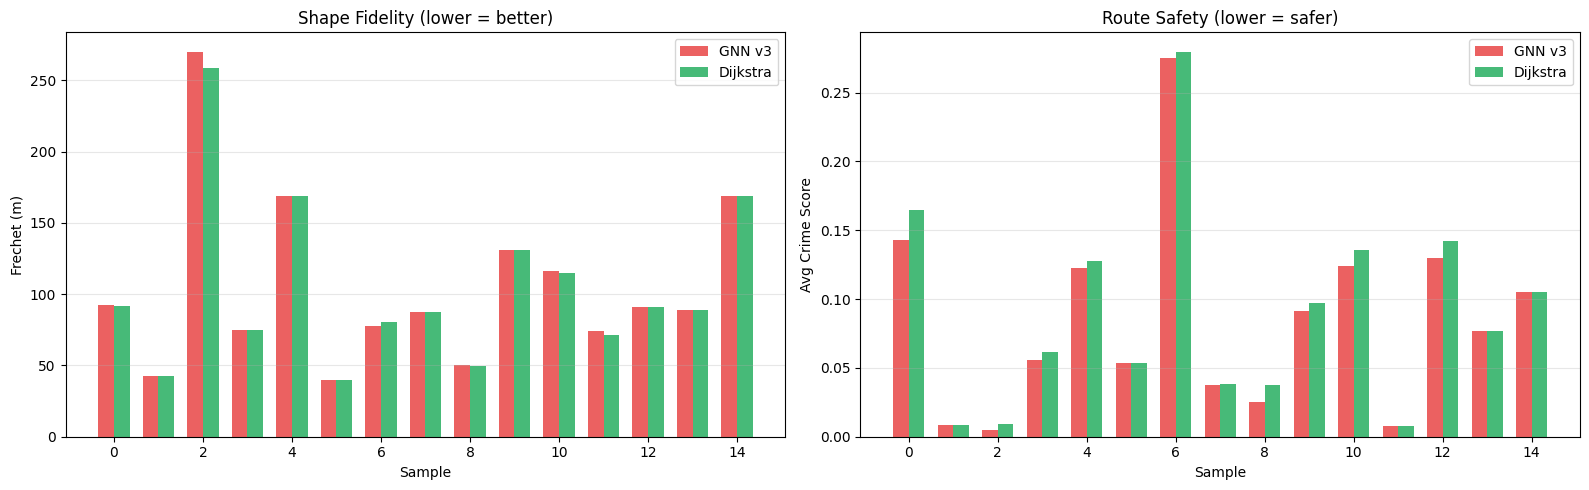

In [60]:
# ──────────────────────────────────────────────────────────────────
# 9.3  Comparison charts
# ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(EVAL_SAMPLES)
w = 0.35

axes[0].bar(x - w/2, frechet_gnn, w, label="GNN v3", color="#E84545", alpha=0.85)
axes[0].bar(x + w/2, frechet_dij, w, label="Dijkstra", color="#27ae60", alpha=0.85)
axes[0].set_xlabel("Sample"); axes[0].set_ylabel("Frechet (m)")
axes[0].set_title("Shape Fidelity (lower = better)")
axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(x - w/2, safety_gnn, w, label="GNN v3", color="#E84545", alpha=0.85)
axes[1].bar(x + w/2, safety_dij, w, label="Dijkstra", color="#27ae60", alpha=0.85)
axes[1].set_xlabel("Sample"); axes[1].set_ylabel("Avg Crime Score")
axes[1].set_title("Route Safety (lower = safer)")
axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()



-- Sample 1 --


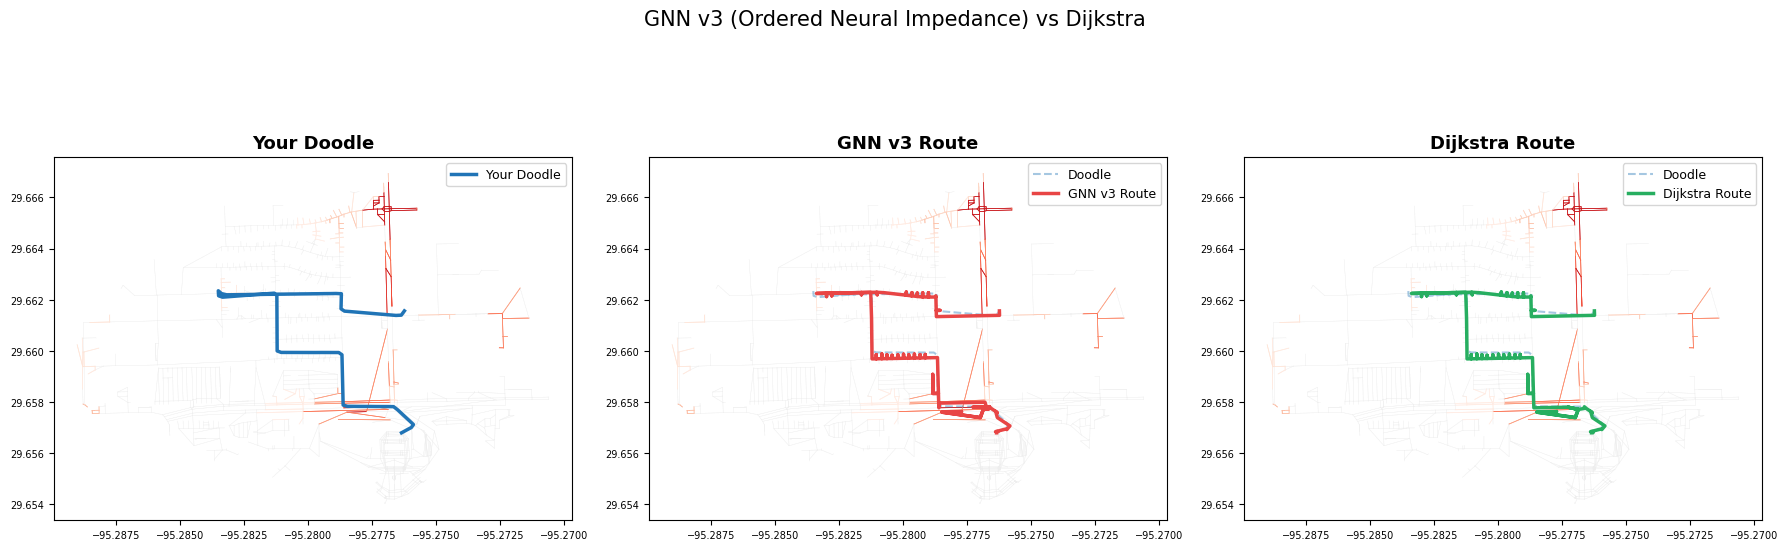


-- Sample 2 --


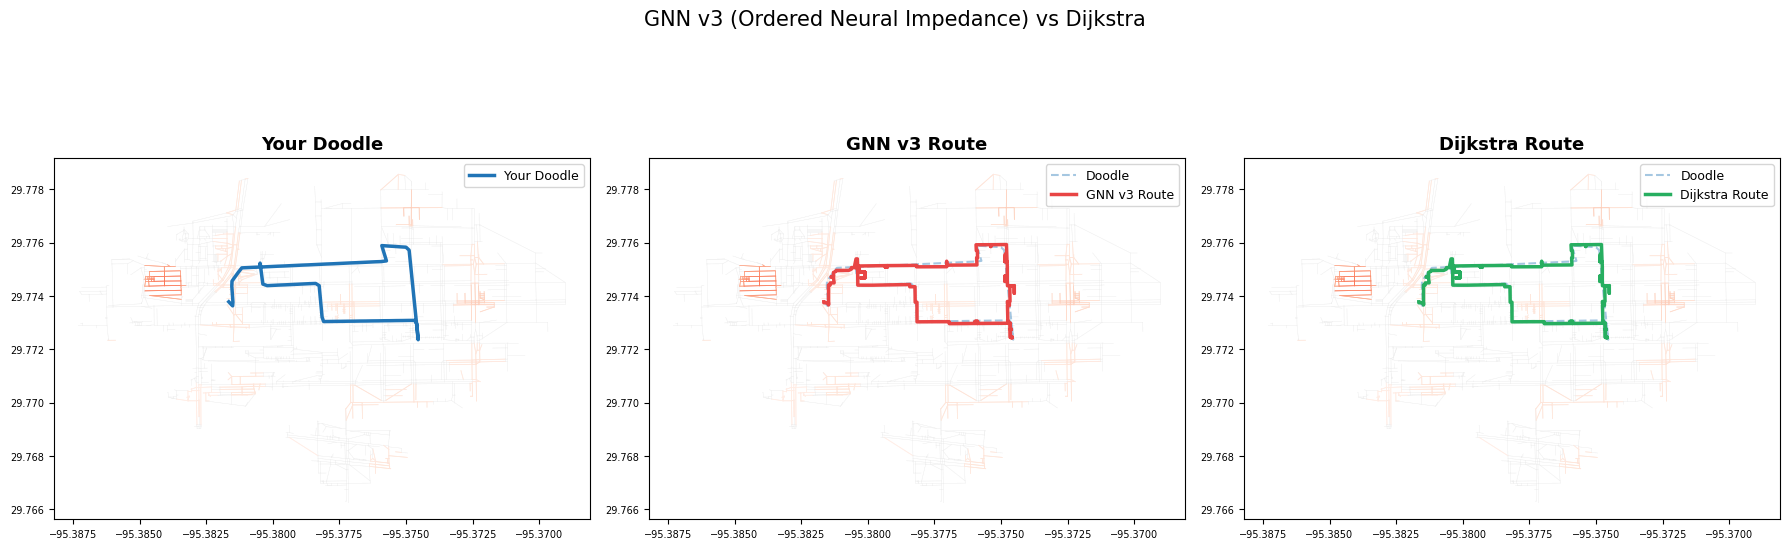


-- Sample 3 --


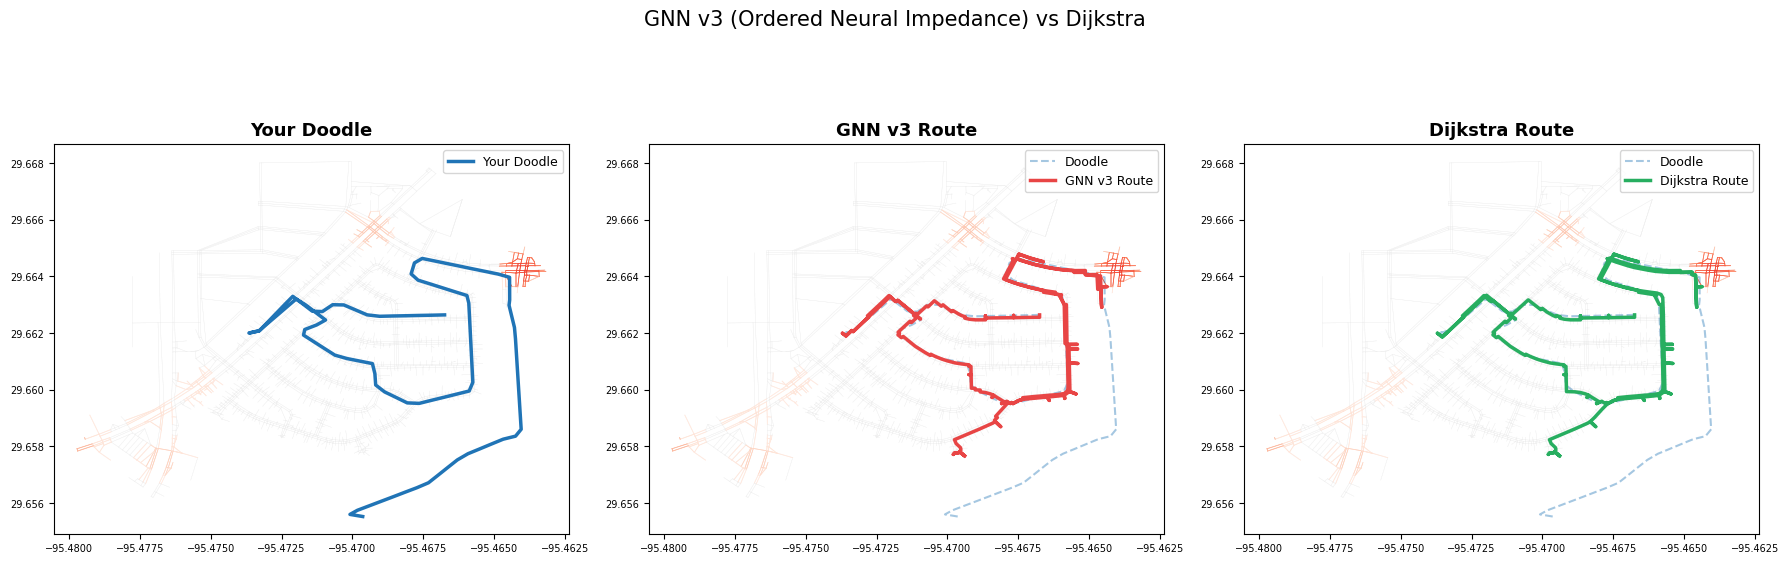

In [61]:
# ──────────────────────────────────────────────────────────────────
# 9.4  Side-by-side route visualisation
# ──────────────────────────────────────────────────────────────────
def plot_comparison(sample, G_local):
    doodle = sample.doodle_coords
    gnn_r = gnn_neural_impedance_route(model, G_local, doodle)
    dij_r = dijkstra_route(G_local, doodle)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, route, color, title in [
        (axes[0], doodle, "#2074b6", "Your Doodle"),
        (axes[1], gnn_r,  "#E84545", "GNN v3 Route"),
        (axes[2], dij_r,  "#27ae60", "Dijkstra Route"),
    ]:
        for u, v, edata in G_local.edges(data=True):
            score = edata.get("crime_score", 0.0)
            ec = plt.cm.Reds(min(score, 1.0) * 0.75) if score > 0.05 else "#eee"
            ax.plot([G_local.nodes[u]["x"], G_local.nodes[v]["x"]],
                    [G_local.nodes[u]["y"], G_local.nodes[v]["y"]],
                    color=ec, linewidth=0.5 if score > 0.05 else 0.2, zorder=1)
        if route != doodle:
            dlats, dlons = zip(*doodle)
            ax.plot(dlons, dlats, "#2074b6", lw=1.5, ls="--", alpha=0.4, label="Doodle", zorder=2)
        if route:
            rlats, rlons = zip(*route)
            ax.plot(rlons, rlats, color, lw=2.5, label=title, zorder=3)
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.legend(loc="upper right", fontsize=9)
        ax.set_aspect("equal")
        ax.tick_params(labelsize=7)
    plt.suptitle("GNN v3 (Ordered Neural Impedance) vs Dijkstra", fontsize=15, y=1.02)
    plt.tight_layout(); plt.show()

for i in range(min(3, len(val_data))):
    print(f"\n-- Sample {i+1} --")
    plot_comparison(val_data[i], val_data[i].subgraph_ref)


In [62]:
# ──────────────────────────────────────────────────────────────────
# 9.5  Interactive Folium comparison map
# ──────────────────────────────────────────────────────────────────
def folium_comparison(sample, G_local):
    doodle = sample.doodle_coords
    gnn_r = gnn_neural_impedance_route(model, G_local, doodle)
    dij_r = dijkstra_route(G_local, doodle)
    lats = [p[0] for p in doodle]
    lons = [p[1] for p in doodle]
    center = [(min(lats) + max(lats)) / 2, (min(lons) + max(lons)) / 2]
    m = folium.Map(location=center, zoom_start=15, tiles="CartoDB positron")
    folium.PolyLine(doodle, color="#2074b6", weight=3, opacity=0.6, dash_array="8 5", tooltip="Doodle").add_to(m)
    if gnn_r:
        s = route_safety_stats(G_local, gnn_r)
        folium.PolyLine(gnn_r, color="#E84545", weight=5, opacity=0.9,
                        tooltip=f"GNN v3 — {route_km(gnn_r):.2f} km | crime {s['crime_avg']:.4f}").add_to(m)
    if dij_r:
        s = route_safety_stats(G_local, dij_r)
        folium.PolyLine(dij_r, color="#27ae60", weight=4, opacity=0.9,
                        tooltip=f"Dijkstra — {route_km(dij_r):.2f} km | crime {s['crime_avg']:.4f}").add_to(m)
    folium.Marker(doodle[0], tooltip="Start", icon=folium.Icon(color="green", icon="play", prefix="fa")).add_to(m)
    folium.Marker(doodle[-1], tooltip="End", icon=folium.Icon(color="red", icon="flag-checkered", prefix="fa")).add_to(m)
    return m


from html import escape as html_escape
from routedoodle_webapp import get_accessible_url, start_static_webpage

comparison_map = folium_comparison(val_data[0], val_data[0].subgraph_ref)
comparison_host = "0.0.0.0" if IN_COLAB else "127.0.0.1"
comparison_page = start_static_webpage(comparison_map, globals(), host=comparison_host, port=8766)

comparison_page_local_url = comparison_page.url
comparison_page_public = None
comparison_page_url = comparison_page_local_url
comparison_public_block = ""

print(f"Local RouteDoodle comparison map running at {comparison_page_local_url}")
print("Starting public comparison-map URL tunnel; this can take 15-45 seconds on a fresh runtime ...", flush=True)

try:
    comparison_page_public = get_accessible_url(
        comparison_page,
        globals(),
        in_colab=IN_COLAB,
        prefer_public=True,
        require_public=True,
    )
    comparison_page_url = comparison_page_public.url
    comparison_public_block = (
        f'<b>Public URL</b><br>'
        f'<a href="{html_escape(comparison_page_url)}" target="_blank" rel="noopener noreferrer">Open {html_escape(comparison_page_url)}</a><br>'
        f'<span style="color:#667085;font-size:13px;">URL mode: {html_escape(comparison_page_public.mode)}. {html_escape(comparison_page_public.detail)}</span><br><br>'
    )
    print(f"Public RouteDoodle comparison map running at {comparison_page_url}")
except Exception as exc:
    tunnel_error = str(exc)
    comparison_public_block = (
        f'<b>Public URL unavailable</b><br>'
        f'<span style="color:#8a4b00;font-size:13px;">Cloudflare or ngrok could not create a reachable public URL.</span><br>'
        f'<span style="color:#667085;font-size:13px;">Reason: {html_escape(tunnel_error)}</span><br>'
        f'<span style="color:#667085;font-size:13px;">The local comparison map is still running. To force ngrok, set NGROK_AUTHTOKEN and ROUTEDOODLE_TUNNEL=ngrok, then rerun this cell.</span><br><br>'
    )
    print("Public comparison-map URL was not created.")
    print(f"Reason: {tunnel_error}")
    print(f"Use the local comparison-map URL on this machine: {comparison_page_local_url}")

comparison_local_block = (
    f'<b>Local URL</b><br>'
    f'<a href="{html_escape(comparison_page_local_url)}" target="_blank" rel="noopener noreferrer">Open {html_escape(comparison_page_local_url)}</a><br>'
    f'<span style="color:#667085;font-size:13px;">Works from the same machine running this notebook. It is not public.</span>'
)

display(HTML(
    f'<div style="background:#f8f9fa;padding:12px 16px;border-radius:8px;'
    f'border-left:4px solid #2074b6;margin-bottom:8px;font-size:14px;">'
    f'<b>RouteDoodle comparison map</b><br><br>'
    f'{comparison_public_block}{comparison_local_block}</div>'
))


Local RouteDoodle comparison map running at http://127.0.0.1:8766/
Starting public comparison-map URL tunnel; this can take 15-45 seconds on a fresh runtime ...
Public RouteDoodle comparison map running at https://glen-frontier-reviewer-path.trycloudflare.com/


---
## 10 · Export & Scaling

The final cells convert generated route coordinates into GPX and KML files under `outputs/`. These exports are independent of the browser tunnel; once a route has been generated in the notebook workflow, the files can be opened in downstream map tools.


In [63]:
# ──────────────────────────────────────────────────────────────────
# 10.1  GPX / KML export
# ──────────────────────────────────────────────────────────────────
def to_gpx(coords, name="RouteDoodle-GNN-v3"):
    pts = "\n".join(f'    <trkpt lat="{lat:.7f}" lon="{lon:.7f}"/>' for lat, lon in coords)
    return ('<?xml version="1.0" encoding="UTF-8"?>\n'
            '<gpx version="1.1" creator="RouteDoodle-GNN-v3" '
            'xmlns="http://www.topografix.com/GPX/1/1">\n'
            f'  <trk><name>{name}</name><trkseg>\n{pts}\n  </trkseg></trk>\n</gpx>')


def to_kml(coords, name="RouteDoodle-GNN-v3"):
    cs = " ".join(f"{lon:.7f},{lat:.7f},0" for lat, lon in coords)
    return ('<?xml version="1.0" encoding="UTF-8"?>\n'
            '<kml xmlns="http://www.opengis.net/kml/2.2"><Document>\n'
            f'  <name>{name}</name>\n'
            f'  <Placemark><LineString><coordinates>{cs}'
            '</coordinates></LineString></Placemark>\n</Document></kml>')

sample = val_data[0]
gnn_r = gnn_neural_impedance_route(model, sample.subgraph_ref, sample.doodle_coords)
if gnn_r:
    OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
    gpx_path = OUTPUT_ROOT / "route_gnn_v3.gpx"
    kml_path = OUTPUT_ROOT / "route_gnn_v3.kml"
    with open(gpx_path, "w") as f:
        f.write(to_gpx(gnn_r))
    with open(kml_path, "w") as f:
        f.write(to_kml(gnn_r))
    print(f"Exported: {gpx_path} and {kml_path} ({route_km(gnn_r):.2f} km)")

Exported: /Users/sajpatel/projects/comp_559/outputs/route_gnn_v3.gpx and /Users/sajpatel/projects/comp_559/outputs/route_gnn_v3.kml (3.83 km)


In [64]:
# try:
#     from google.colab import runtime
# except ModuleNotFoundError:
#     runtime = None

# if runtime is not None:
#     runtime.unassign()
# else:
#     print("Not running in Colab — skipping runtime.unassign().")

---
## Summary — RouteDoodle GNN v3

| Pillar | Component | Key Math |
|--------|-----------|----------|
| **1** | `DoodleEncoder` (1-D CNN) | $f_\theta: \text{Doodle} \to \mathbb{R}^{32}$, tiled to all nodes |
| **2** | Ordered Composite Loss | $\mathcal{L} = \mathcal{L}_{\text{BCE}} + 0.2\mathcal{L}_{\text{anchor}} + 0.4\mathcal{L}_{\text{safety}}$ |
| **3** | Neural Impedance | $W = \text{length} \cdot \frac{1}{P+0.01} \cdot \frac{1 + 2.5\,\text{crime}}{\max(0.75, 1 + 0.25\,\text{amenity})}$ |
| **4** | Safety Features | `crime_score`, `danger_overlap`, `lit`, `sidewalk`, `crossing` |

The v3 pipeline is designed for zero-cache Colab runs, ordered doodle supervision, and route generation that balances shape fidelity with safer edges.
